Проект выполнен на Python 3.12.6

Используемые библиотеки:

In [2]:
import pandas as pd
import numpy as np
import json
import re
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='white', context='notebook', palette='deep')
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import skew
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import norm

import xgboost as xgb
from sklearn.linear_model import LinearRegression,LassoCV, Ridge, LassoLarsCV,ElasticNetCV, ElasticNet, Lasso,  BayesianRidge, LassoLarsIC
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve, train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, Normalizer, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import make_pipeline
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
import xgboost as xgb

%config InlineBackend.figure_format = 'retina' 
%matplotlib inline

Этап 1.

Знакомство с данными. Первичная обработка признаков.

In [2]:
#Прежде всего нужно загрузить данные из файла:
data = pd.read_csv('data/house_data.csv')
data.head()

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"
3,for sale,NaN,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",yes,Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","6,457 sqft",75205,5 Beds,TX,3.0,NaN,NaN,14191809,"$2,395,000"
4,for sale,NaN,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",NaN,Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...",NaN,32908,NaN,FL,NaN,NaN,NaN,861745,"$5,000"


Сразу же, без выполнения всякого анализа, можно увидеть сразу три бесполезных для моделирования признака:
почтовый индекс - zipcode; и две (скорее всего, дублирующие друг друга) версии идентификатора объектов недвижимости,
используемого риэлторскими агентствами в США (Multiple Listing Service) - mls-id и MlsId. Убираем их из рабочего датасета (предварительно создав резервные копии в отдельной переменной).

In [4]:
identificators = data[['zipcode', 'mls-id', 'MlsId']]
data = data.drop(labels=['zipcode', 'mls-id', 'MlsId'], axis=1)

Посмотрим на все оставшиеся после этого признаки:

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   status        337267 non-null  object
 1   private pool  4181 non-null    object
 2   propertyType  342452 non-null  object
 3   street        377183 non-null  object
 4   baths         270847 non-null  object
 5   homeFacts     377185 non-null  object
 6   fireplace     103114 non-null  object
 7   city          377151 non-null  object
 8   schools       377185 non-null  object
 9   sqft          336608 non-null  object
 10  beds          285903 non-null  object
 11  state         377185 non-null  object
 12  stories       226469 non-null  object
 13  PrivatePool   40311 non-null   object
 14  target        374704 non-null  object
dtypes: object(15)
memory usage: 43.2+ MB


*Разговор о большом количестве пропусков*

In [6]:
data = data.dropna(subset=['target', 'city', 'street'], axis=0)

*Разговор о форматирвании признаков*

In [7]:
def get_numeric(string):
    try:
        result = re.sub(r"[^0-9|.]", "", string)
        return float(result)
    except:#Это нужно для правильной обработки функцией пропущенных значений
        return np.nan
#Тестовый пуск функции
print(get_numeric('$310,000'))
print(get_numeric('2.5 baths'))

310000.0
2.5


In [8]:
for column in ['target', 'baths', 'beds', 'sqft', 'stories']:
    data.loc[:, column] = data[column].apply(get_numeric)
    data[column] = data[column].astype(float)

Теперь займёмся извлечением полезной информации из обоих JSON-признаков. Сначала посмотрим на их структуру, чтобы разобраться подробнее в том, что нужно будет сделать:

In [9]:
print(data['homeFacts'][0])
print(data['schools'][0])

{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': 'Central A/C, Heat Pump', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': None, 'factLabel': 'lotsize'}, {'factValue': '$144', 'factLabel': 'Price/sqft'}]}
[{'rating': ['4', '4', '7', 'NR', '4', '7', 'NR', 'NR'], 'data': {'Distance': ['2.7 mi', '3.6 mi', '5.1 mi', '4.0 mi', '10.5 mi', '12.6 mi', '2.7 mi', '3.1 mi'], 'Grades': ['3–5', '6–8', '9–12', 'PK–2', '6–8', '9–12', 'PK–5', 'K–12']}, 'name': ['Southern Pines Elementary School', 'Southern Middle School', 'Pinecrest High School', 'Southern Pines Primary School', "Crain's Creek Middle School", 'Union Pines High School', 'Episcopal Day Private School', 'Calvary Christian Private School']}]


*Здесь обзор структуры объектов*

In [10]:
#Создадим вспомогательную функцию для удобного перевода JSON-литералов в удобный для обработки вид
def json_string_formatter(json_string):
    json_string = json_string.replace('\'s', '')
    json_string = json_string.replace('\'', '"')
    json_string = json_string.replace('\\', '')
    json_string = json_string.replace('\"\"', 'null')
    json_string = json_string.replace('None', 'null')
    return json_string 

Создадим функцию для извлечения из JSON-объектов, находящихся в колонке homeFacts, значений произвольного признака, представленного в виде одной из JSON-записей внутри JSON-массива "atAGlanceFacts". Сначала нужно идентифицировать признак-запись по его имени (значению ключа factLabel), а затем извлечь его собственное значение по ключу factValue. Обратите внимание, что имя нужного нам признака находится во внешней для функции переменной column_name. Это позволит нам легко использовать функцию в цикле, чтобы извлечь сразу несколько признаков.

In [11]:
def home_facts_parser(json_string):
    try:
        json_string = json_string_formatter(json_string)
        json_data = json.loads(json_string)['atAGlanceFacts']

        for item in json_data:
            if item['factLabel'] == column_name:
                return item['factValue']
    except:
        return np.nan 
#Тестовый пуск функции   
column_name = 'Year built'
home_facts_parser(data['homeFacts'][0])

'2019'

Для безопасности данных пока будем извлекать признаки из JSON-колонок в отдельную таблицу. Извлечём информацию о всех признаках, кроме Price/sqft - он нам не нужен, так как напрямую зависит от целевой переменной и привёл бы к утечке данных при попытках использовать его в создании модели.

In [12]:
data_from_json = pd.DataFrame()

for column in ['Year built', 'Remodeled year', 'lotsize',
               'Heating', 'Cooling', 'Parking']:
    column_name = column
    data_from_json.loc[:, column] = data['homeFacts'].apply(home_facts_parser)

Признак schools слишком сложен, так как содержит информацию сразу о нескольких ближайших школах, каждая - с несколькими характеристиками, и при этом признак ещё и имеет неоднородную структуру. Целесообразно будет кардинально упростить его, учитывая информацию только о самой ближайшей к дому школе. Создадим функции для извлечения информации о расстоянии до ближайшей школы и о её рейтинге.

In [13]:
def get_nearest_school_distance(json_string):
    try:
       json_string = json_string_formatter(json_string)
       json_data = json.loads(json_string)[0]

       distance_list = pd.Series(json_data['data']['Distance'])
       distance_list = distance_list.apply(lambda x: float(x[:-3]))
       return distance_list.min()
    except:
        return np.nan 
    
def get_nearest_school_rating(json_string):
    try:
        json_string = json_string_formatter(json_string)
        json_data = json.loads(json_string)[0]

        distance_list = pd.Series(json_data['data']['Distance'])
        distance_list = distance_list.apply(lambda x: float(x[:-3]))
        ratings_list = json_data['rating']

        for i in range(len(distance_list)):
            if distance_list[i]==distance_list.min():
                return ratings_list[i]
    except:
        return np.nan
    
#Тестовый пуск функций
print(get_nearest_school_distance(data['schools'][0]))
print(get_nearest_school_rating(data['schools'][0]))

2.7
4


In [14]:
data_from_json['nearest_school_distance'] = data['schools'].apply(get_nearest_school_distance)
data_from_json['nearest_school_rating'] = data['schools'].apply(get_nearest_school_rating)

Помимо о расстояния до и рейтинга ближайшей школы, в объектах колонки schools также имеется информация о типе учебного заведения, притом в двух версиях - в массиве grades и в названии школы (предпоследнее слово в названии школы - ...Elementary School, Intermediate School e.t.c.) На всякий случай спарсим обе версии.

In [15]:
def get_nearest_school_type1(json_string):
    try:
        json_string = json_string_formatter(json_string)
        json_data = json.loads(json_string)[0]

        distance_list = pd.Series(json_data['data']['Distance'])
        distance_list = distance_list.apply(lambda x: float(x[:-3]))
        types_list = json_data['data']['Grades']

        for i in range(len(distance_list)):
            if distance_list[i]==distance_list.min():
                return types_list[i]
    except:
        return np.nan

def get_nearest_school_type2(json_string):
    try:
        json_string = json_string_formatter(json_string)
        json_data = json.loads(json_string)[0]

        distance_list = pd.Series(json_data['data']['Distance'])
        distance_list = distance_list.apply(lambda x: float(x[:-3]))
        names_list = json_data['name']

        for i in range(len(distance_list)):
            if distance_list[i]==distance_list.min():
                name = names_list[i]
                return name.split()[-2]
    except:
        return np.nan

#Тестовый пуск функций
print(get_nearest_school_type1(data['schools'][0]))
print(get_nearest_school_type2(data['schools'][0]))

3–5
Elementary


In [16]:
data_from_json['nearest_school_type1'] = data['schools'].apply(get_nearest_school_type1)
data_from_json['nearest_school_type2'] = data['schools'].apply(get_nearest_school_type2)

Теперь посмотрим на "распакованные" признаки:

In [17]:
data_from_json.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374668 entries, 0 to 377184
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Year built               312276 non-null  object 
 1   Remodeled year           149835 non-null  object 
 2   lotsize                  313273 non-null  object 
 3   Heating                  265716 non-null  object 
 4   Cooling                  251291 non-null  object 
 5   Parking                  199852 non-null  object 
 6   nearest_school_distance  365406 non-null  float64
 7   nearest_school_rating    365406 non-null  object 
 8   nearest_school_type1     365251 non-null  object 
 9   nearest_school_type2     364898 non-null  object 
dtypes: float64(1), object(9)
memory usage: 39.5+ MB


*Заметить большое количество пропусков*

Добавим признаки назад в исходный датафрейм и посмотрим, что у нас получилось:

In [18]:
for column in data_from_json.columns:
    data[column] = data_from_json[column]

#Теперь можно избавиться от ставших ненужными JSON-колонок:
data = data.drop(labels=['homeFacts', 'schools'], axis=1)

data.head()

,status,private pool,propertyType,street,baths,fireplace,city,sqft,beds,state,...,Year built,Remodeled year,lotsize,Heating,Cooling,Parking,nearest_school_distance,nearest_school_rating,nearest_school_type1,nearest_school_type2
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,Gas Logs,Southern Pines,2900.0,4.0,NC,...,2019,None,None,"Central A/C, Heat Pump",None,None,2.7,4,3–5,Elementary
1,for sale,NaN,single-family home,12911 E Heroy Ave,3.0,NaN,Spokane Valley,1947.0,3.0,WA,...,2019,None,5828 sqft,None,None,None,1.0,4/10,PK-8,Elementary
2,for sale,NaN,single-family home,2005 Westridge Rd,2.0,yes,Los Angeles,3000.0,3.0,CA,...,1961,1967,"8,626 sqft",Forced Air,Central,Attached Garage,1.1,8/10,6-8,Middle
3,for sale,NaN,single-family home,4311 Livingston Ave,8.0,yes,Dallas,6457.0,5.0,TX,...,2006,2006,"8,220 sqft",Forced Air,Central,Detached Garage,0.0,9/10,PK-4,Elementary
4,for sale,NaN,lot/land,1524 Kiscoe St,NaN,NaN,Palm Bay,NaN,NaN,FL,...,None,None,"10,019 sqft",None,None,None,3.0,5/10,PK-6,Elementary


In [26]:
data['lotsize'] = data['lotsize'].apply(get_numeric)
data['Year built'] = data['Year built'].apply(get_numeric)
data['Remodeled year'] = data['Remodeled year'].apply(get_numeric)

for column in ['beds', 'stories', 'sqft', 'lotsize', 'Year built', 'Remodeled year']:
    data[column] = data[column].fillna(value=(-1))
    data[column] = data[column].astype(int)

In [23]:
def parse_school_rating(string):
    try:
        string = string.split(sep='/')[0]
        if string.isnumeric():
            return int(string)
        else:
            return np.nan
    except:#Нужно для обработки пропущенных значений.
        return np.nan
    
#Тестовый пуск функции:
parse_school_rating('7/10')

7

In [24]:
data['nearest_school_rating'] = data['nearest_school_rating'].apply(parse_school_rating)

In [29]:
data['nearest_school_type1'].value_counts()[:15]

nearest_school_type1
PK-5              87676
9-12              40100
6-8               33015
Preschool to 5    29615
K-5               27451
PK-8              15295
PK–5              10110
PK-6               8354
6 to 8             7923
K-6                7345
K–5                5843
9–12               5673
Preschool to 8     5638
K to 5             5450
9 to 12            5349
Name: count, dtype: int64

In [35]:
def parse_school_type(string):
    try:
        string = string.replace(' to ', '-')
        string = string.replace('Preschool', 'K')
        string = string.replace('PK', 'K')
        return string
    except:
        return np.nan

data['nearest_school_type1'] = data['nearest_school_type1'].apply(parse_school_type)
data['nearest_school_type1'].value_counts()[:10]

nearest_school_type1
K-5     150192
9-12     45449
6-8      40938
K-8      27218
K-6      17612
K–5      15953
K-4       9147
K–8       6622
9–12      5673
K–12      3757
Name: count, dtype: int64

In [36]:
data['nearest_school_type2'].value_counts()[:10]

nearest_school_type2
Elementary      175494
High             52969
Middle           41453
Private          11179
K-8               4976
Intermediate      2094
School            1911
Academy           1812
Charter           1617
Park              1129
Name: count, dtype: int64

In [37]:
def is_private(string):
    if string=='Private' or string=='Academy':
        return 1
    else:
        return 0
    
data['private school'] = data['nearest_school_type2'].apply(is_private)

In [38]:
def custom_labeler(string):
    mapping = {'K-5':'Elementary', 'K–5':'Elementary', '9-12':'High', 
               '9–12':'High', '6-8':'Middle', '6–8':'Middle', 'K-8': 'K-8', 'K–8': 'K-8'}
    if string in mapping.keys():
        return mapping[string]
    else:
        return 'Other'
    
data['nearest_school_type1'] = data['nearest_school_type1'].apply(custom_labeler)
data['nearest_school_type1'].value_counts()

nearest_school_type1
Elementary    166145
Other          79652
High           51122
Middle         43909
K-8            33840
Name: count, dtype: int64

In [39]:
data['nearest_school_type2'] = data['nearest_school_type2'].apply(lambda x: np.nan if x=='Private' or x=='Academy' else x)
data['nearest_school_type'] = data['nearest_school_type2'].fillna(value=data['nearest_school_type1'])
data = data.drop(labels=['nearest_school_type1', 'nearest_school_type2'], axis=1)
data['nearest_school_type'].value_counts()

nearest_school_type
Elementary    176950
High           53745
Middle         41582
Other          16665
K-8             8711
               ...  
Flagg              1
Gap                1
Rouse              1
Set                1
Alderson           1
Name: count, Length: 2040, dtype: int64

In [40]:
data['pool'] = data['private pool'].fillna(value=data['PrivatePool'])
data = data.drop(labels=['private pool', 'PrivatePool'], axis=1)

In [42]:
for column in ['beds', 'stories', 'sqft', 'lotsize', 'Year built', 'Remodeled year']:
    data[column] = data[column].apply(lambda x: np.nan if x<0 else x)

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374668 entries, 0 to 377184
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   status                   335412 non-null  object 
 1   propertyType             340114 non-null  object 
 2   street                   374668 non-null  object 
 3   baths                    267837 non-null  float64
 4   fireplace                102521 non-null  object 
 5   city                     374668 non-null  object 
 6   sqft                     333737 non-null  float64
 7   beds                     374668 non-null  int64  
 8   state                    374668 non-null  object 
 9   stories                  374668 non-null  int64  
 10  target                   374668 non-null  float64
 11  Year built               311093 non-null  float64
 12  Remodeled year           149835 non-null  float64
 13  lotsize                  251328 non-null  float64
 14  Heating  

Этап 2. 

Очистка и предварительный анализ данных.

In [3]:
data = pd.read_csv('data/house_data_prepared.csv').drop(labels='Unnamed: 0', axis=1)

In [4]:
data.head()

,status,propertyType,street,baths,fireplace,city,sqft,beds,state,stories,...,Remodeled year,lotsize,Heating,Cooling,Parking,nearest_school_distance,nearest_school_rating,private school,nearest_school_type,pool
0,Active,Single Family Home,240 Heather Ln,3.5,Gas Logs,Southern Pines,2900.0,4,NC,0,...,NaN,NaN,"Central A/C, Heat Pump",NaN,NaN,2.7,4.0,0,Elementary,NaN
1,for sale,single-family home,12911 E Heroy Ave,3.0,NaN,Spokane Valley,1947.0,3,WA,2,...,NaN,5828.0,NaN,NaN,NaN,1.0,4.0,0,Elementary,NaN
2,for sale,single-family home,2005 Westridge Rd,2.0,yes,Los Angeles,3000.0,3,CA,1,...,1967.0,8626.0,Forced Air,Central,Attached Garage,1.1,8.0,0,Middle,yes
3,for sale,single-family home,4311 Livingston Ave,8.0,yes,Dallas,6457.0,5,TX,3,...,2006.0,8220.0,Forced Air,Central,Detached Garage,0.0,9.0,0,Elementary,NaN
4,for sale,lot/land,1524 Kiscoe St,NaN,NaN,Palm Bay,NaN,0,FL,0,...,NaN,10019.0,NaN,NaN,NaN,3.0,5.0,0,Elementary,NaN


Сначала отыщем выбросы в целевой переменной:

In [5]:
print(data['target'].min())
print(data['target'].max())

1.0
195000000.0


*Описание выбросов цены*

In [6]:
print(data['target'].quantile(q=0.03))
print(data['target'].quantile(q=0.97))

20000.0
2799000.0


*Описание границ цены*

In [7]:
data = data[(data['target']>20000)&(data['target']<2800000)]
print(data.shape[0])

351991


*Создание валидационной выборки*

In [8]:
thresh = round(data.shape[0] * 0.9)

valid = data[thresh:]
valid.to_csv('data/house_data_valid.csv')
data = data[:thresh]

Посмотрим теперь, как распределена целевая переменная в наших данных:


 mu = 463041.47 and sigma = 447384.85



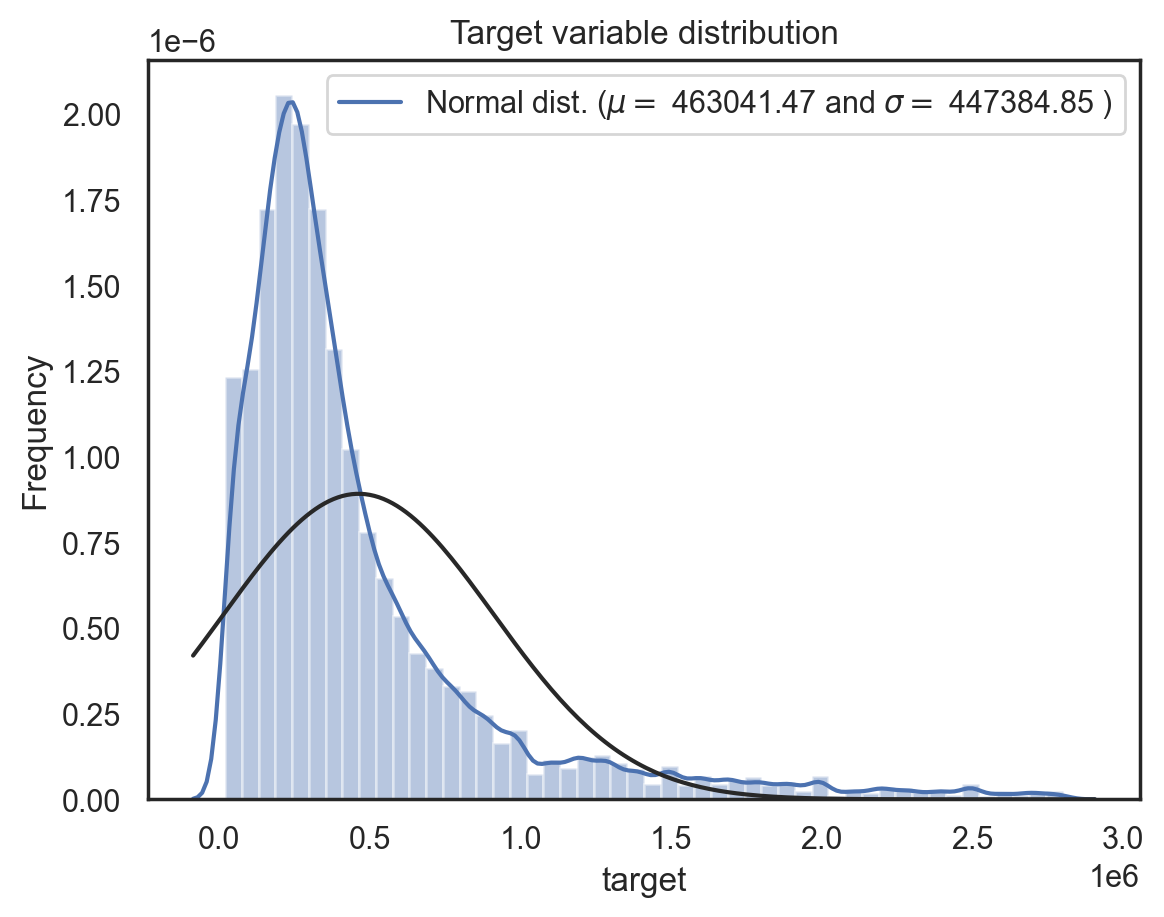

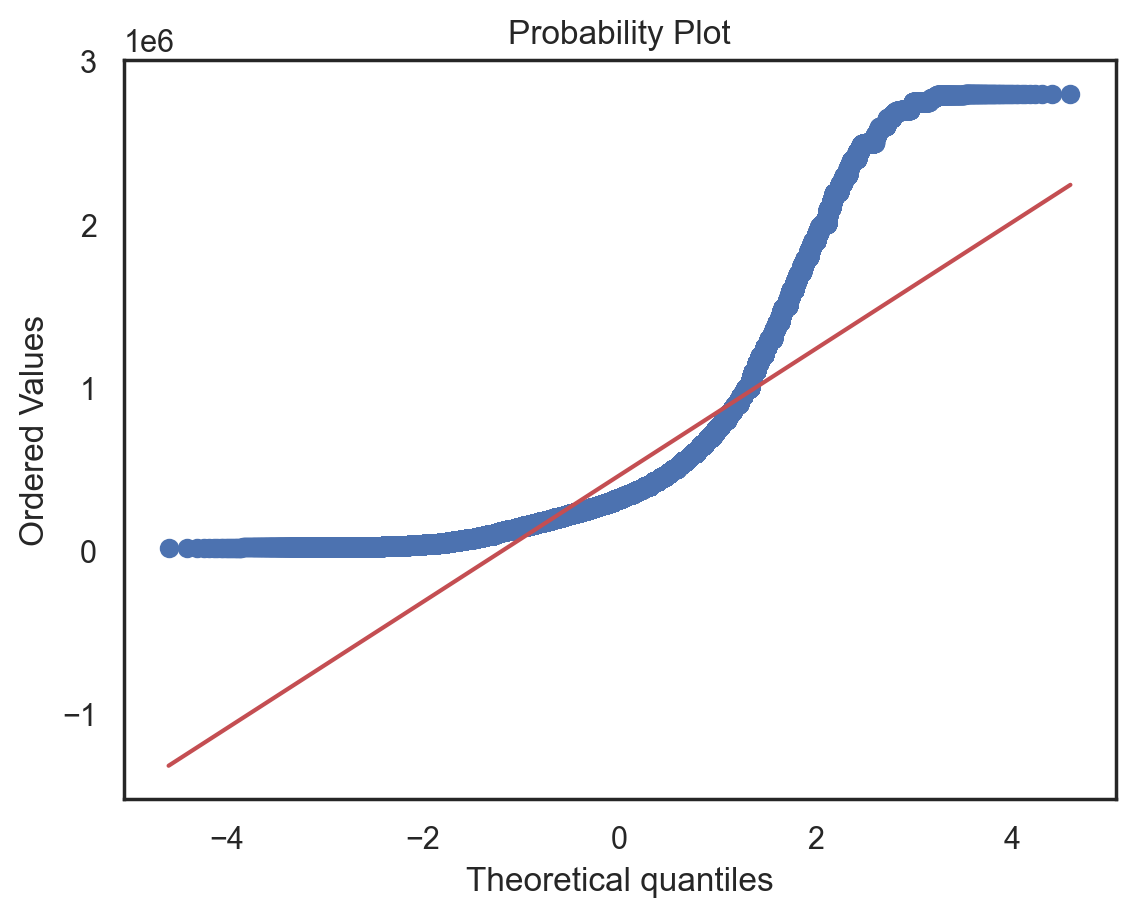

Skewness: 2.332963
Kurtosis: 6.299640


In [9]:
sns.distplot(data['target'], fit=norm)

(mu, sigma) = norm.fit(data['target'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('Target variable distribution')

fig = plt.figure()
res = stats.probplot(data['target'], plot=plt)
plt.show()

print("Skewness: %f" % data['target'].skew())
print("Kurtosis: %f" % data['target'].kurt())

*Вывод об искривлённости целевой переменной*

In [10]:
print(data['sqft'].min())
print(data['sqft'].max())

print(data['lotsize'].min())
print(data['lotsize'].max())

0.0
795979430.0
0.0
2147483647.0


*Первое упоминание типа домов*

In [11]:
data['propertyType'].value_counts()[:10]

propertyType
single-family home               78998
Single Family                    53874
Single Family Home               27992
condo                            22108
lot/land                         14760
Condo                            14218
townhouse                        10077
Condo/Townhome/Row Home/Co-Op     6894
Land                              6812
multi-family                      6535
Name: count, dtype: int64

In [12]:
zero_sqft = data[data['sqft']==0]
zero_sqft['propertyType'].value_counts()

propertyType
Land                             6792
Single Family Home                410
Farms/Ranches                     152
Condo/Townhome/Row Home/Co-Op     116
Multi-Family Home                 102
Mfd/Mobile Home                    16
Other                               9
Name: count, dtype: int64

*То, что нулевая площадь пола - норма для участка земли, доказано*

In [13]:
data['sqft'] = data['sqft'].apply(lambda x: np.nan if x==0 else x)
data['lotsize'] = data['lotsize'].apply(lambda x: np.nan if x==0 else x)

filler = data['propertyType'].apply(lambda x:0 if x=='Land' else np.nan)
data['sqft'] = data['sqft'].fillna(value=filler)

data['lotsize'] = data['lotsize'].fillna(value=data['sqft'])

*Подведение к форматированию типа домов*

In [14]:
data['propertyType'] = data['propertyType'].fillna(value='unknown')
data['propertyType'] = data['propertyType'].apply(lambda x: x.lower().replace('-', ' ').replace('family home', 'family'))
data['propertyType'].value_counts()

propertyType
single family                                                 160864
condo                                                          36326
unknown                                                        27504
townhouse                                                      16130
lot/land                                                       14760
                                                               ...  
condo/townhome, hi rise, contemporary/modern, southwestern         1
2 stories, ranch, traditional                                      1
custom, patio                                                      1
rancher, traditional                                               1
farmhouse/national folk, contemporary                              1
Name: count, Length: 1169, dtype: int64

Single family, traditional, и detatched - все эти слова должны обозначать одно и тоже - традиционный частный дом для одной семьи. Видно, что таких домов - абсолютное большинство от всех продаваемых объектов (одна только категория single family содержит более 160 тысяч записей - уже около половины от 310 тысяч записей, оставшихся в данных после откладывания валидационной выборки.) В принципе, составление такими домами большинства соответствует здравому смыслу.

Проблему из себя представляют такие категории как condo (коммунальный дом) или townhouse (многоквартирный дом) - непонятно, представляют ли они из себя предложение продажи квартиры в таких домах, или всего дома? Возможность того, что часть лотов в данных представляет из себя высотные здания, продающиеся целиком (например, какому-то крупному бизнесу), нельзя отрицать - ведь мы уже видели, что самые дорогие из домов в наших данных стоят почти 3 миллиона долларов, что сравнимо со стоимостью целого многоэтажного здания. 

Посмотрим, сколько многоэтажек есть в наших данных. Будем считать многоэтажным здание больше чем в 3 этажа высотой.

In [15]:
high_rise = data[data['stories']>3]
print(f'There are {high_rise.shape[0]} high-rise buildings in the data')

There are 8971 high-rise buildings in the data


In [16]:
high_rise['propertyType'].value_counts()[:10]

propertyType
condo                                       6006
coop                                         966
single family                                608
townhouse                                    419
condo/townhome/row home/co op                237
cooperative                                  140
multi family                                  92
contemporary/modern                           89
condominium (single level), contemporary      76
apartment                                     53
Name: count, dtype: int64

Большинство из многоэтажных домов действительно принадлежит к типу condo. Однако при этом среди них есть и значения с припиской single level (один этаж). Это может быть сигналом, что значения признака stories могут быть непоследовательными и для части объектов обозначать этаж здания, на котором находится квартира, а для другой части - количество этажей в здании.

Можно попытаться разрешить это затруднение, создав вспомогательный признак отношения площади пола дома к заявленному количеству этажей. Для предотвращения ошибок заменим все пропуски и нули в признаке количества этажей на единицы (Скорее всего, если для постройки не указано количество этажей, на самом деле у неё всего один этаж. Большинство нулевых значений количества этажей скорее всего соответсвуют участкам земли без построек. Можно просто условиться, что у "голого" участка земли всегда есть один этаж.)  

In [17]:
data['stories'] = data['stories'].fillna(value=1)
data['stories'] = data['stories'].apply(lambda x: 1 if x==0 else x)

data['sqft_per_storey'] = data['sqft'] / data['stories']

Заодно можно сразу избавиться и от выбросов в другую (большую) сторону в признаке количества этажей. Будем считать выбросом все небоскрёбы (дома с 30 и более этажами).

In [18]:
skyscrapers = data[data['stories']>=30].shape[0]
print(f'There are alleged {skyscrapers} skysrapers in the data')

There are alleged 341 skysrapers in the data


In [19]:
data = data[data['stories']<30]

Будем считать кандидатом в целое многоквартирное здание объекты недвижимости более чем в два этажа высотой, у которой на каждый этаж приходится более 6000 кв. футов площади (что по идее должно позволить поместить на каждый этаж три-четыре не слишком больших квартиры).

In [20]:
possibly_a_tower_block = ((data['sqft_per_storey']>6000) & (data['stories']>2))

data[possibly_a_tower_block]['propertyType'].value_counts()

propertyType
coop             267
apartment         19
cooperative       15
condo              6
single family      5
multi family       2
townhouse          1
lot/land           1
Name: count, dtype: int64

Как ни странно, среди наших кандидатов есть несколько объектов типа single family и lot/land. Скорее всего, это ошибки в данных, хотя возможно - и какие-то трёхэтажные мега-поместья для очень богатых семей. В любом случае, такие единичные аномалии пока можно не трогать. 

Если наш метод выявления целых многоквартирных зданий верен, их медианная стоимость должна быть намного больше, чем у остальных объектов в датасете. Проверим, так ли это.

In [21]:
print(data[possibly_a_tower_block]['target'].median())
print(data[~possibly_a_tower_block]['target'].median())

549000.0
320000.0


Эффективность нашего метода неоднозначна - хотя медианная стоимость наших кандидатов в многоквартирые дома действительно больше, чем у остальной части датасета, она больше всего в полтора-два раза, а не на порядки, как по логике вещей должна была бы различаться стоимость квартиры и целого многоквартирного дома. Наиболее реалистичным объяснением является то, что, хотя в датасете и есть информация о продаже целиком многоквартирных домов, все они являются относительно небольшими (не больше трёх этажей в высоту, скорее всего состоят только из двух-трёх подъездов), и поэтому стоят не намного дороже очень большого частного дома. Но в таком случае выбросом надо считать все целиком продающиеся высотные здания в наших данных.

In [22]:
print(f'{sum((data['sqft_per_storey']>6000) & (data['stories']>3))} alleged offers for whole high-rise buildings found in the data.')

305 alleged offers for whole high-rise buildings found in the data.


In [23]:
data = data[(data['sqft_per_storey']<=6000)|(data['stories']<=3)]

Итак, у нас нет высотных зданий, продающихся целиком, что сделает нашу будущую модель непригодной для работы с этим типом недвижимости. Все объекты в датасете с числом этажей N большим, чем 3, нужно считать всего лишь квартирами на этаже N. Для устранения неоднозначности признак stories было бы идеальным разделить на два - количество этажей в самом продающемся объекте (всегда было бы равно 1 для квартиры) и этаж в здании, на котором находится объект (можно было бы принять за 0 для отдельно стоящих домов и для участков земли без построек), но к сожалению, сделать это без дополнительной информации не представляется возможным - нельзя придумать даже относительно надёжный способ отличить предложение о продаже большой квартиры на втором этаже от предложения по продаже целого небольшого двухэтажного многоквартирного дома.

Теперь классифицируем все возможные значения признака propertyType на пять категорий: urban - городской (многоквартирный) дом или же квартира в нём, suburban - пригородный (частный, отдельно построенный) дом, rural -сельский дом (возможно, с большим участком), land - участок земли без построек, и unknown - "неизвестно". После небольшой работы с признаком propertyType я составил в ячейке ниже словарь, классифицирующий по этим категориям большую часть значений признака propertyType:

In [39]:
cust_dict = {'urban_home' : ['condo', 'coop', 'cooperative', 'townhouse', 'multi family', 'condo/townhome/row home/co op', 'condominium',
            'condominium (single level)', 'condominium (single level), contemporary', 'apartment', 'contemporary', 'high rise'] , 
            'suburban_home' : ['single family', 'traditional', 'detached, one story', 'single detached, traditional', '1 story', '2 story', '2 stories'],
            'rural_home' : ['ranch', 'farm', 'lot/land', 'farms/ranches', 'farm/ranch'], 'land' : ['land']}

def classify_property(string):
    for key in cust_dict.keys():
        if string in cust_dict[key]:
            return key
    else:
        return 'unknown'
    
#data['propertyType'] = data['propertyType'].apply(classify_property)

Теперь мы наконец-то можем вернуться к анализу площадей наших объектов. Посмотрим, как распределены площади полов у разных типов недвижимости.

(-0.5, 4.5, 0.0, 5000.0)

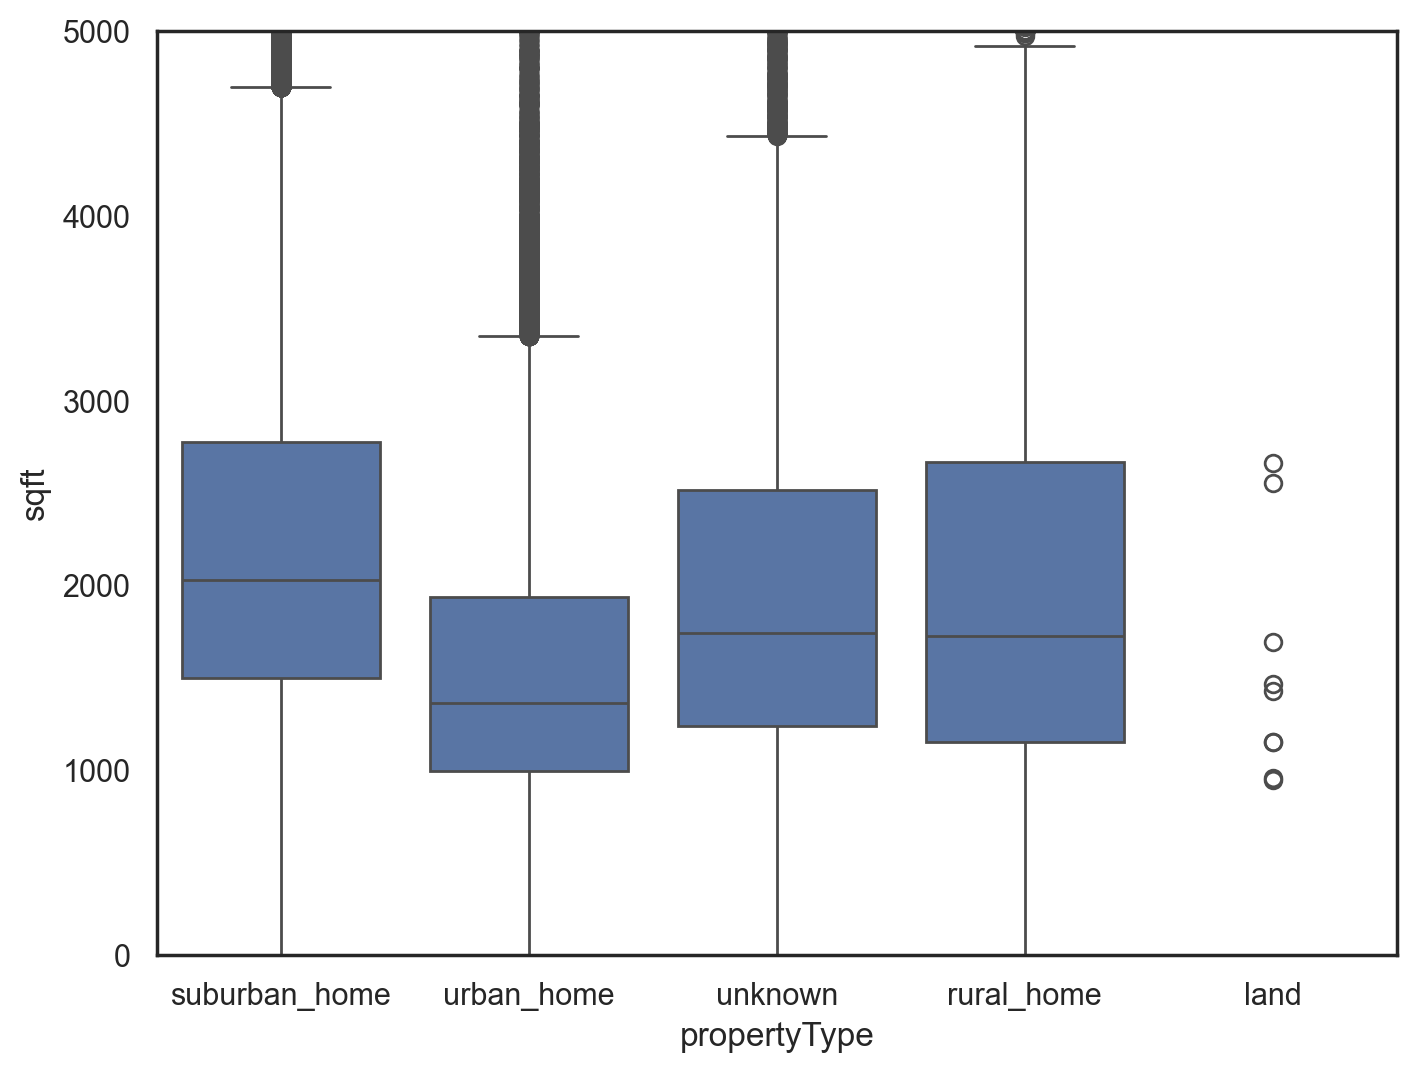

In [25]:
f, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x='propertyType', y='sqft', data=data)
fig.axis(ymin=0, ymax=5000)

Как видно, средняя площадь частного пригородного дома - около 2000 кв. футов, сельского дома - около 1500 кв. футов, а квартриры - около 1250 кв. футов, что соответствует здравому смыслу. Меньше всего колеблется площадь квартир, больше всего - сельских домов, что, судя по диаграмее, объясняется существованием большого количества маленьких сельских домов (площадью от 1000 кв.футов), когда самые большие из них почти такой же площади, как и самые большие из пригородных домов. Объекты с ненулевой площадью в категории land являются выбросами и должны быть удалены.

In [26]:
data = data[(data['sqft']==0)|(data['propertyType']!='land')]

Теперь посмотрим на распределение площадей участков:

(-0.5, 4.5, 0.0, 65000.0)

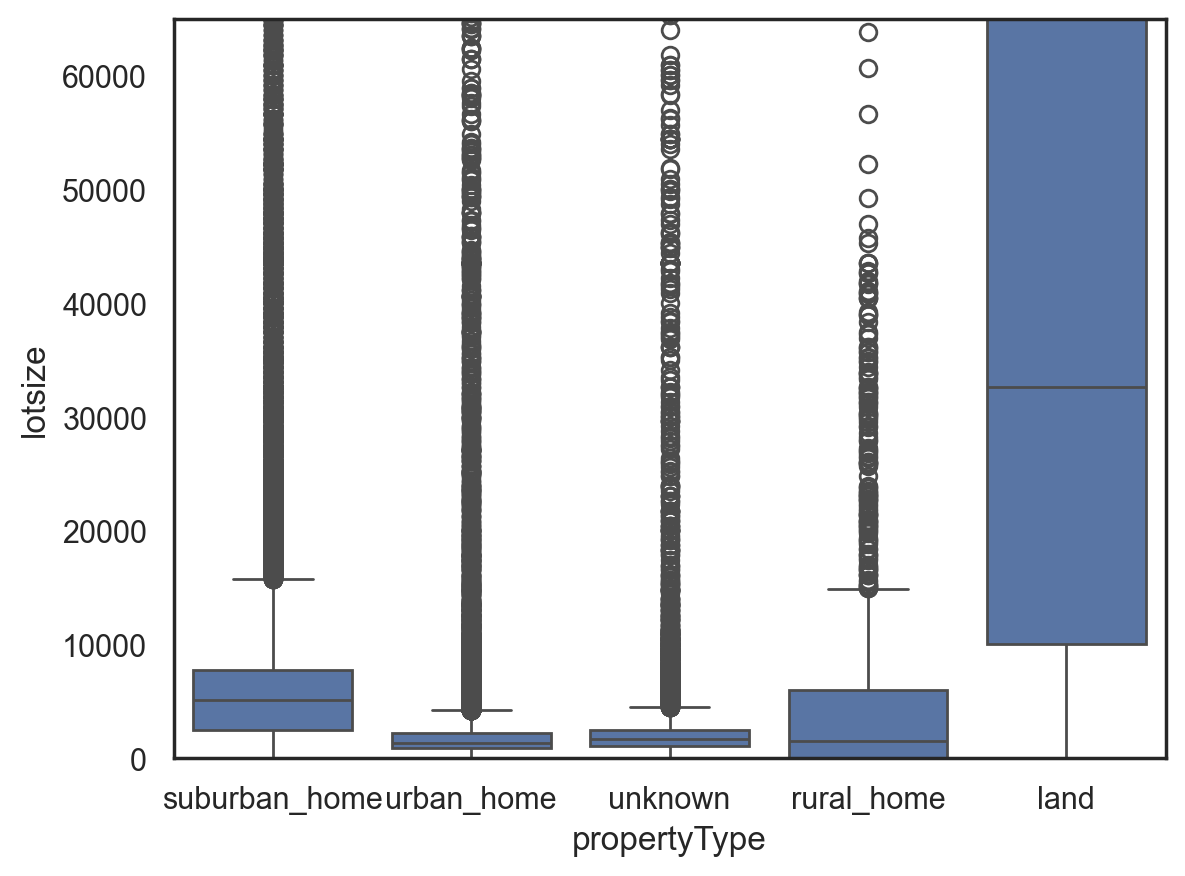

In [27]:
fig = sns.boxplot(x='propertyType', y='lotsize', data=data)
fig.axis(ymin=0, ymax=65000)

Большинство продаваемых участков земли очень большие (12000 кв. футов и более, а в среднем - площадью около 40000 кв. футов), намного больше, чем любой участок земли вокруг постройки...

Аномалией являются сельские дома с очень маленькой площадью участка. Аномально маленькие площади участка можно исправить, заменив их на соответствующие площади этажа (ведь самая маленькая площадь участка, которая может быть - это площадь первого этажа дома, стоящего на ней - в случае, если дом занимает 100% территории).

In [28]:
data['lotsize'] = data['lotsize'].apply(lambda x: np.nan if x<1000 else x).fillna(value=data['sqft_per_storey'])

С другой стороны, вокруг квартиры участка быть не может, поэтому площадь участка больше, чем площадь пола квартиры также является выбросом. Заменим такие площади на площади пола:

In [29]:
shibboleth = data['stories'].apply(lambda x: 0 if x>3 else 1)
data['lotsize'] = (data['lotsize'] * shibboleth).apply(lambda x: np.nan if x==0 else x)
data['lotsize'] = data['lotsize'].fillna(value=data['sqft_per_storey'])

In [30]:
outliers = (data['sqft']>5000) | ((data['lotsize']>40000) & (data['propertyType']!='land'))
print(data[outliers].shape[0])

11713


In [31]:
data = data[~outliers]
data.shape[0]

304172

Ещё одним видом выбросов являются "невозможные" здания, площадь пола одного этажа которых превышает размер участка, на котором они находятся. 

In [32]:
value = data[data['sqft_per_storey'] > data['lotsize']].shape[0]
print('There are {} "imposssible" buildings in the data'.format(value))

There are 2395 "imposssible" buildings in the data


Удалим из датасета и их тоже:

In [33]:
data =data[data['sqft_per_storey']<=data['lotsize']]

Теперь, после избавления от выбросов, мы можем заняться заполнением пропусков. Заполним пропуски в площадх пола и площадях участка медианнным значением для соответствующего типа недвижимости.

In [34]:
med_sqft = {}
med_lotsize = {}

for prop_type in ['suburban_home', 'urban_home', 'rural_home', 'land', 'unknown']:
    subset = data[data['propertyType']==prop_type]
    med1, med2 = subset['sqft'].median(), subset['lotsize'].median()
    med_sqft[prop_type] = med1
    med_lotsize[prop_type] = med2

data['sqft'] = data['sqft'].fillna(value=data['propertyType'].apply(lambda x: med_sqft[x]))
data['lotsize'] = data['lotsize'].fillna(value=data['propertyType'].apply(lambda x: med_lotsize[x]))

Посмотрим, сильно ли изменилась корелляция между площадью пола и площадью участка:

In [35]:
data[['sqft', 'lotsize']].corr()

,sqft,lotsize
sqft,1.000000,-0.007966
lotsize,-0.007966,1.000000


Корелляция всё ещё очень маленькая, но заметно больше, чем прежде. Кроме того, на корреляцию сильно должны влиять большие участки земли без построек (с нулевой площадью пола). Посмотрим, какой корелляция является только для зданий:

In [36]:
buildings = data[data['propertyType']!='land']
buildings[['sqft', 'lotsize']].corr()

,sqft,lotsize
sqft,1.000000,0.242776
lotsize,0.242776,1.000000


Похоже, мы избавились от всех аномалий, связанных с площадями. Посмотрим теперь на связь между площадью дома и ценой:

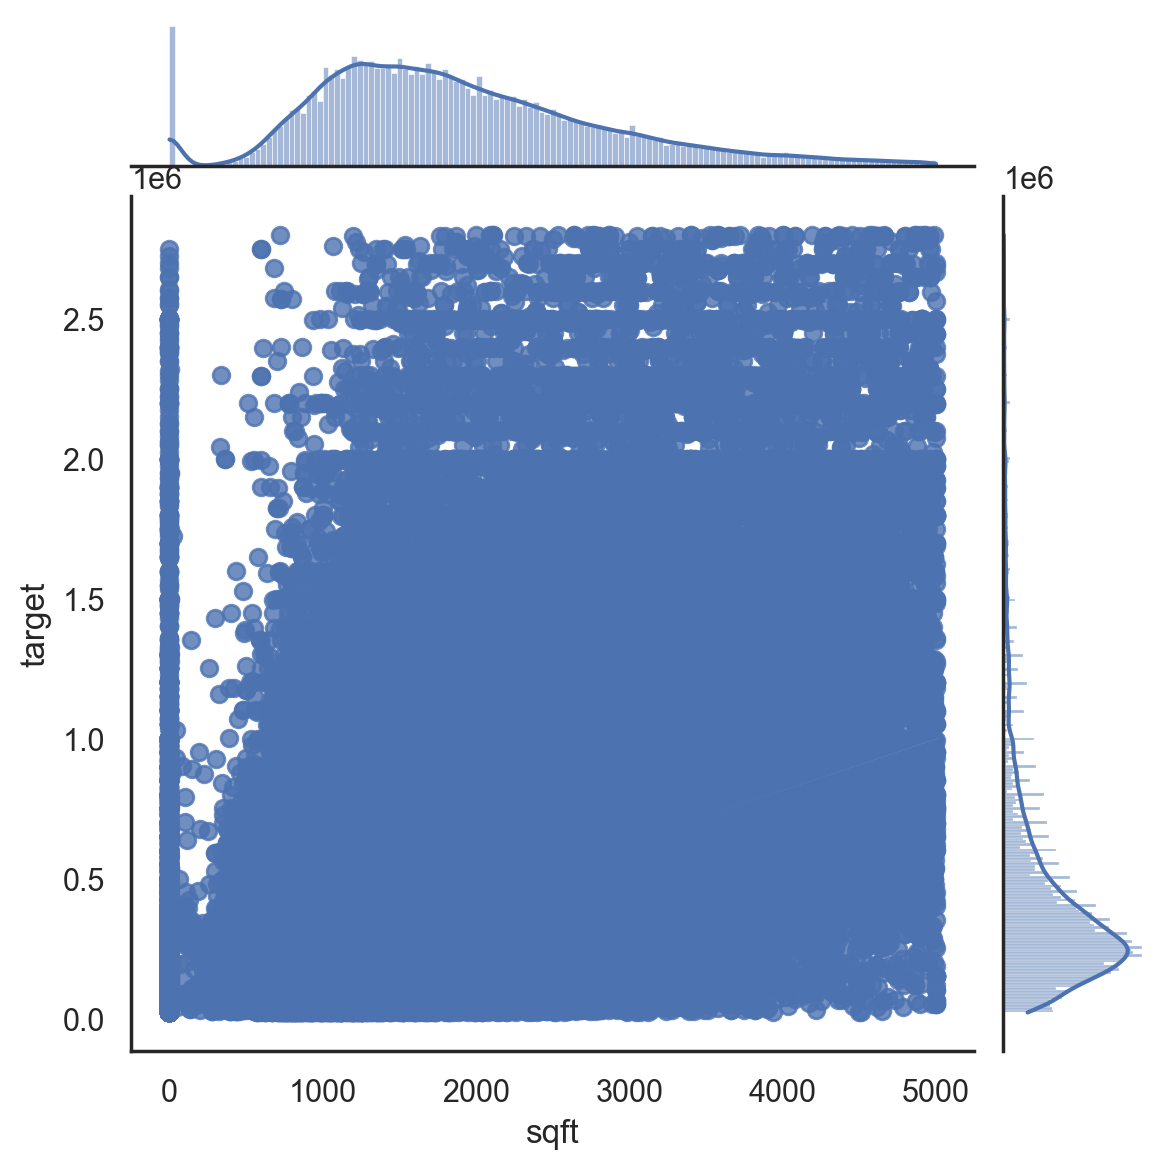

In [37]:
sns.jointplot(x=data['sqft'], y=data['target'], kind='reg')

Как ни странно, между площадью дома пола дома и его ценой не наблюдается почти никакой связи. Хотя из графика и видно, что дома площадью менее 1000 кв.футов почти никогда не стоят много (а также видны участи земли без домов в виде вертикального столбца с левого края), с увеличением площади цены становится практически равномерно "распылены" по всему диапазону между несколькими тысячами и двумя с половиной миллионами долларов. Возможно, понять, что это значит, можно, взглянув на связь между площадью и ценой для отдельных типов домов? 

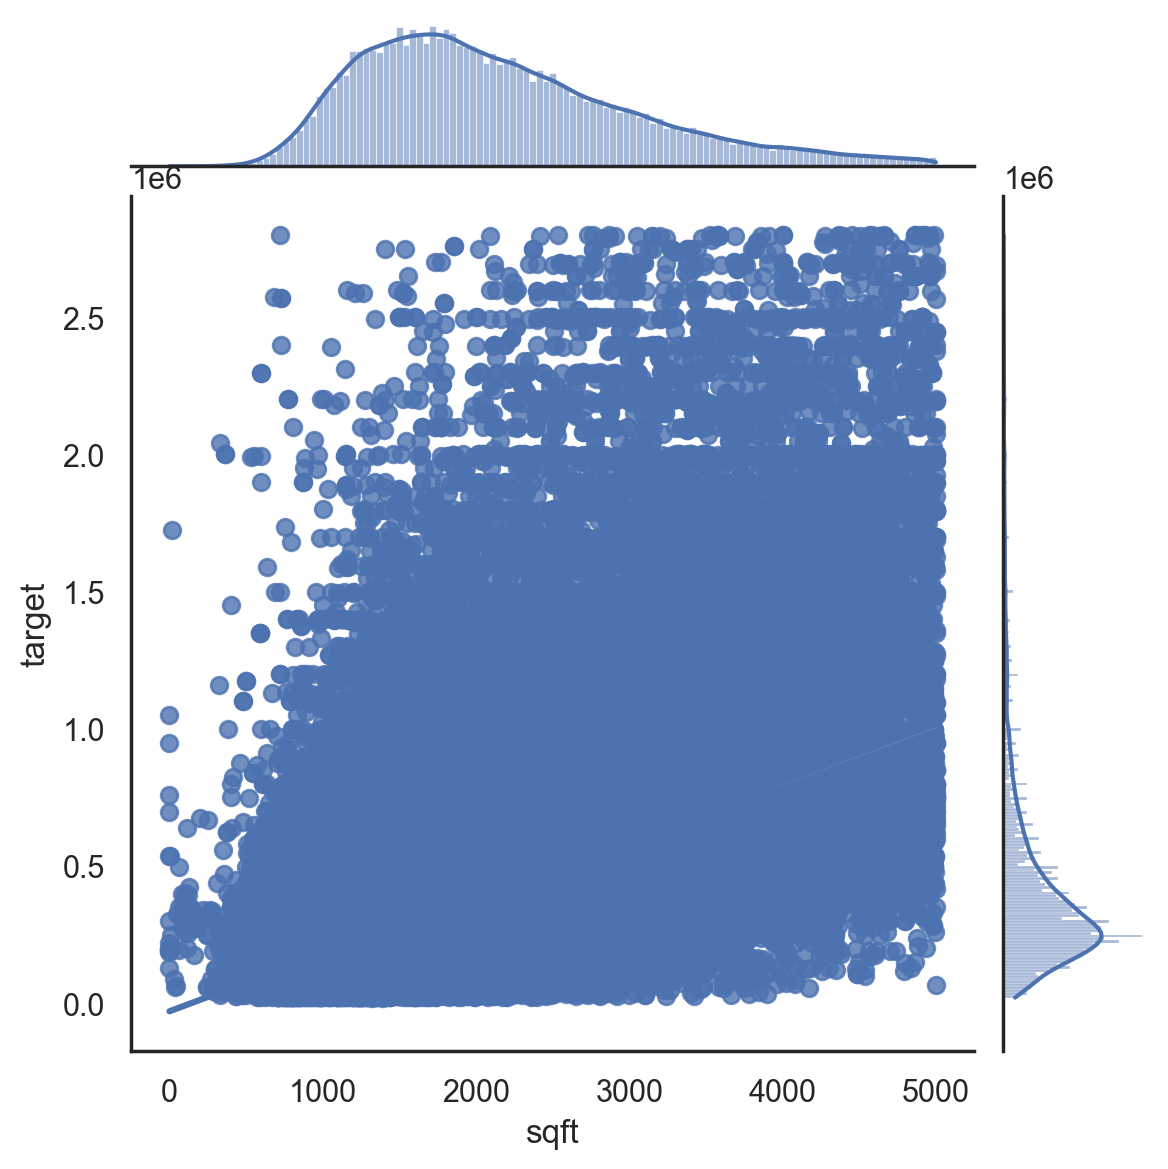

In [38]:
single_family = data[data['propertyType']=='suburban_home']
sns.jointplot(x=single_family['sqft'], y=single_family['target'], kind='reg')

Даже для отдельного типа собственности ситуация в целом такая же. Возможно, в данных есть большое количество предложений о продаже больших, но плохо обустроенных или даже недостроенных домов? Дома ценой более двух с половиной миллионов долларов, но площадью менее 2000 кв.футов в принципе можно попробовать объяснить элитностью города или района, где они расположены, или какой-то особой роскошью убранства, но факт остаётся фактом: признак площади пола очень сильно зашумлен и скорее всего, малоинформативен. Тем не менее, автор работы принял решение оставить площадь пола в данных, как один из немногих имеющихся у него в наличии количественных признаков, и в теории - один из важнейших для предсказания стоимости недвижимости.

Теперь перейдём к признакам baths и beds. Начнём с избавления от выбросов. Так как мы установили, что среди продающихся объектов нет целых высотных домов, выбросом можно считать любой объект с более чем 30 кроватями и 15 ванными комнатами (оставляем себе пространоство для манёвра, т.к. возможно в данных есть продающиеся целиком небольшие многоквартирные дома).

In [39]:
outliers = (data['baths']>15) | (data['beds']>30)
print(f'There are {sum(outliers)} obvious outliers')

There are 11192 obvious outliers


In [40]:
data = data[~outliers]

Однако для частного или сельского дома выбросом можно считать и наличие более 10 кроватей или 5 целых ванных комнат. Для участка же земли без постоек выбросом вообще нужно считать любое ненулевое количество кроватей или ванных.

In [41]:
outliers_1 = (((data['baths']>5) | (data['beds']>10)) & ((data['propertyType']=='suburban_home') | (data['propertyType']=='rural_home'))) 
outliers_2 = ((data['baths']>0) | (data['beds']>0)) & (data['propertyType']=='land')            

print(f'Now there are {sum(outliers_1|outliers_2)} outliers')

Now there are 1711 outliers


In [42]:
data = data[~(outliers_1|outliers_2)]

Теперь заполним пропуски в количествах ванных и кроватей наиболее часто встречающимися значениями для данного типа недвижимости.

In [43]:
mode_baths = {}
mode_beds = {}

for prop_type in ['suburban_home', 'urban_home', 'rural_home', 'land', 'unknown']:
    subset = data[data['propertyType']==prop_type]
    mode1, mode2 = subset['baths'].mode()[0], subset['beds'].mode()[0]
    mode_baths[prop_type] = mode1
    mode_beds[prop_type] = mode2

data['baths'] = data['baths'].fillna(value=data['propertyType'].apply(lambda x: mode_baths[x]))
data['beds'] = data['beds'].fillna(value=data['propertyType'].apply(lambda x: mode_beds[x]))

Посмотрим на зависимость цены от количества кроватей в доме.

(-0.5, 9.5, 0.0, 1000000.0)

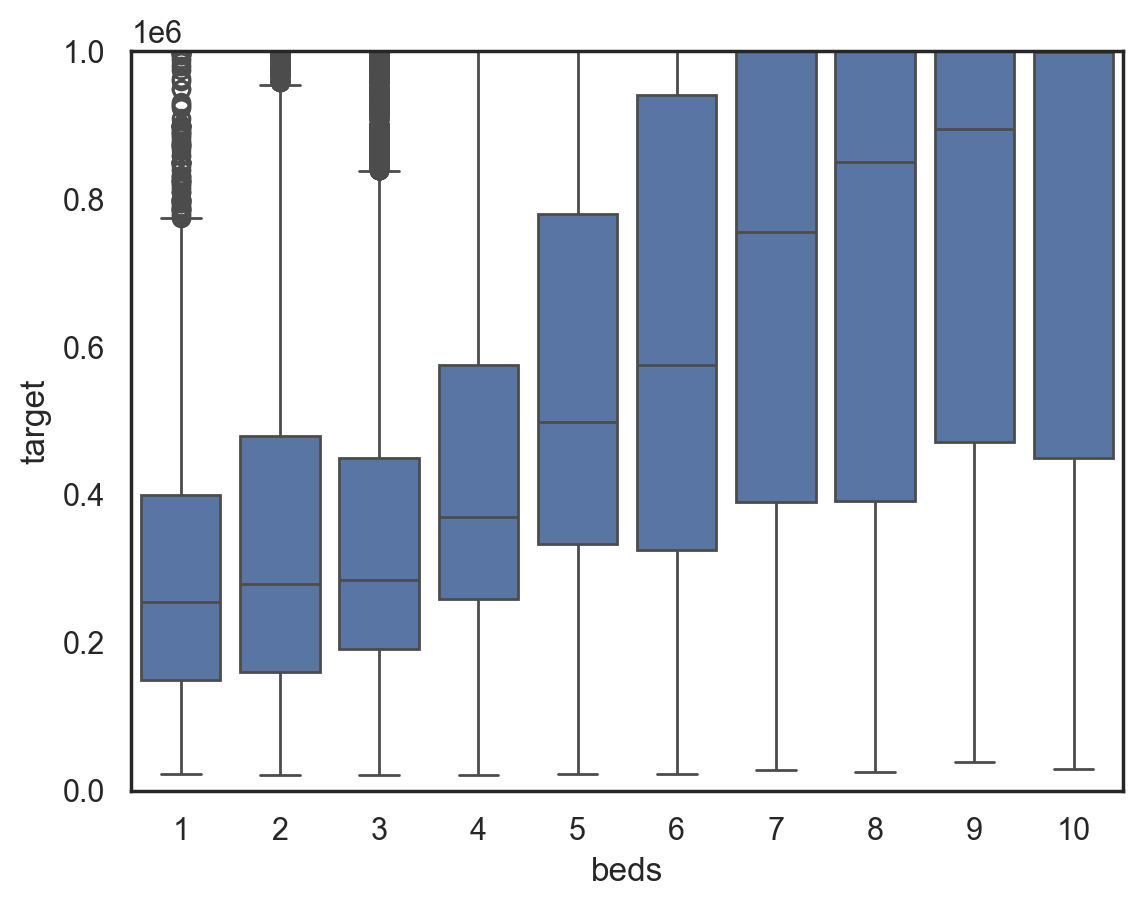

In [44]:
for_visualising = data[(data['beds']>0)&(data['beds']<=10)]

fig = sns.boxplot(x='beds', y='target', data=for_visualising)
fig.axis(ymin=0, ymax=1000000)

Видно, что люди платят больше за большее количество кроватей, что соответствует здравому смыслу.

Для более удобной визуализации распределения дены по количеству ванных, используем вместо последнего не само количество ванных, а количество четвертей ванных, которое всегда должно быть целым числом.

(-0.5, 7.5, 0.0, 1000000.0)

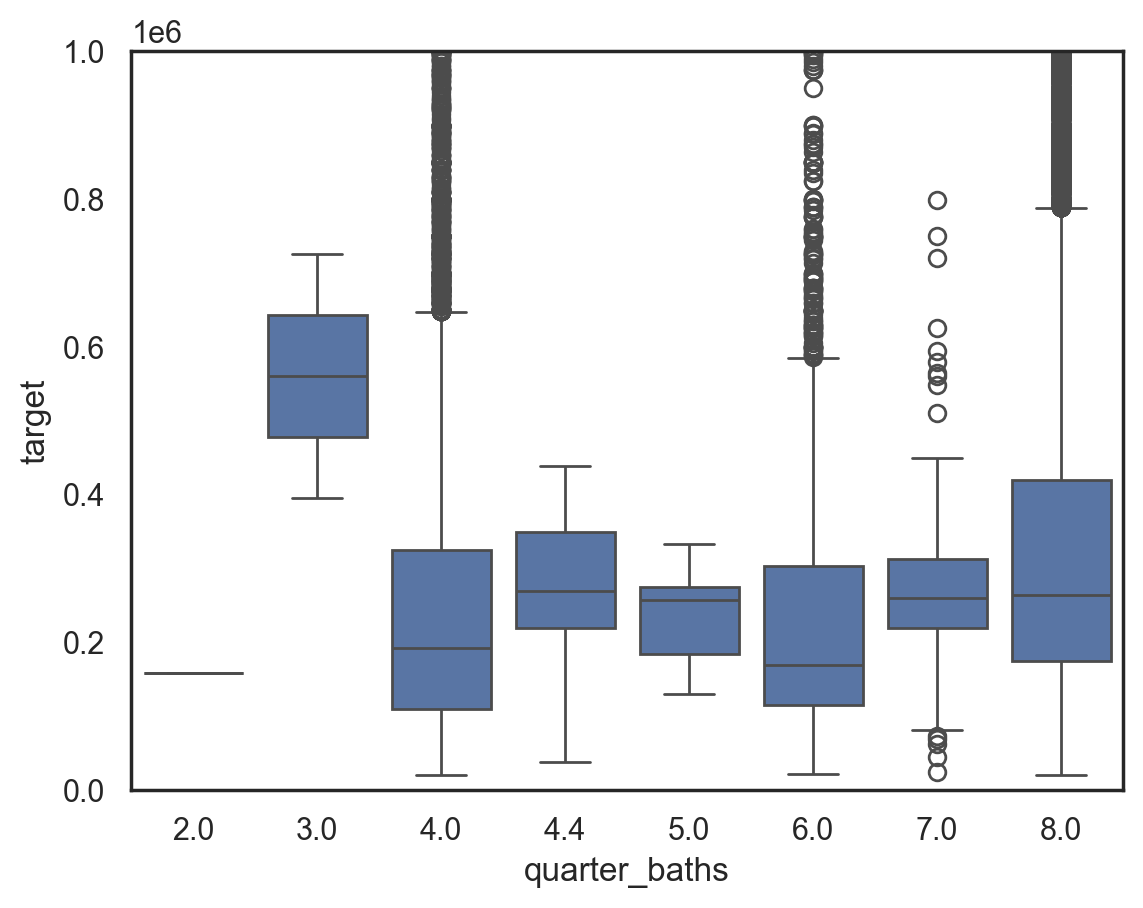

In [45]:
for_visualising = data[(data['baths']>0)&(data['baths']<=2)]
for_visualising['quarter_baths'] = for_visualising['baths'] * 4

fig = sns.boxplot(x='quarter_baths', y='target', data=for_visualising)
fig.axis(ymin=0, ymax=1000000)

Как ни странно, прямой зависимости цены дома от количества ванных не наблюдается. Более того, дома с тремя четвертями ванной комнаты (что скорее всего означает ванную комнату без душа) стоят намного дороже любых других домов, включая дома с полностью укомплектованной ванной комнатой. Скорее всего, это значит, что заполнение пропусков в признаке baths было неудачным и создало большое количество артефактов, обессмыслив этот признак. Удалим его, чтобы увеличить точность будущей модели. Заодно удалим и вспомогательный признак sqft_per_storey, который нам больше не понадобится.

In [46]:
data = data.drop(labels=['baths', 'sqft_per_storey'], axis=1)

Мы наконец-то завершили работу с основными количественными характеристиками объектов недвижимости и с их типами. Теперь признак типа объекта можно спокойно превратить в несколько индикаторных признаков. Обратите внимание, что значение unknown в индикатор превращать не надо из-за его искуственной (сводной) натуры.

In [47]:
for prop_type in ['urban_home', 'suburban_home', 'rural_home', 'land']:
    data[prop_type] = data['propertyType'].apply(lambda x: 1 if x==prop_type else 0)

data = data.drop(labels=['propertyType'], axis=1)

Теперь перейдём к обзору категорий трёх жилищных систем, информация о которых имеется в данных - отопления, кондиционирования, и парковки. Подвергнем эти признаки процедуре устранения одинаковых значений, написанных по разному, аналогичной той, что была проделана над признаком propertyType ранее, а затем составим сводную таблицу 15 самых часто встречающихся значений:

In [48]:
feat_brief = pd.DataFrame()

for column in ['Heating', 'Cooling', 'Parking']:
    data[column] = data[column].fillna(value='no data')
    data[column] = data[column].apply(lambda x: x.lower().replace('-', ' '))
    feat_brief[column] = data[column].value_counts()[:15].index
    feat_brief[column+' count'] = data[column].value_counts()[:15].values

feat_brief.head(15)

,Heating,Heating count,Cooling,Cooling count,Parking,Parking count
0,forced air,108161,central,127705,no data,110703
1,no data,61468,no data,78429,attached garage,56472
2,other,23206,central air,10849,2 spaces,23625
3,heat pump,7191,has cooling,6420,1 space,12076
4,electric,6127,central electric,4633,detached garage,10586
5,gas,5985,wall,3339,carport,6523
6,central air,5148,central gas,2360,off street,4308
7,central electric,4983,cooling system,2019,3 spaces,3453
8,central,4362,central a/c,1534,1,2360
9,"central, electric",3325,other,1410,2,2259


Данные признаки содержат мало полезной информации, в основном - из-за большого числа перекрывающихся и/или ортогональных категорий. Так, большинство значений признака Heating составляет forced air - система "активного" воздушного отопления, в которой теплоносителем выступает горячий воздух, разогреваемый в печи, а затем распространяющийся по дому через систему труб, а меньшинтво - heat pump, система "пассивного" воздушного отопления, предназначенная для мест с тёплым климатом, в которой согретый Солнцем тёплый воздух снаружи дома закачивается внутрь помещения, обогревая его. Однако обозначение forced air ничего не говорит о том, на чём работает печь, разогревающая воздух - на природном газе, на электричестве, или на твёрдом топливе. При этом среди значений также есть gas и electricity - которые наоборот, обозначают тип топлива потребляемый отопительной системой, но ничего не говорят об используемом системой теплоносителе.

Ещё хуже дело обстоит с признаком Cooling - большинство значений признака составляет значение central, которое лишь сообощает о наличии централизованной системы кондиционирования, но ничего не говорит о её устройстве, а на втором месте по популярности стоит значение-заглушка no data, которым мы заменили пропущенные значения. 

Большую часть значений признака Parking тажке составляют пропущенные значения, а среди оставшихся значений можно выделить два типа: значения, обозначающие тип парковки или гаража, и значения, обозначающие, сколько машин он/она вмещает. Больше всего пристроенных к дому (attached) гаражей, все другие типы парковок составляют лишь малые доли.

Автор данной работы посчитал целесообразным попытаться "спасти" лишь признак Parking, а признаки Heating и Cooling удалить.

Из признака Parking можно попробовать реконструировать информацию о количестве частных парковочных мест, доступных у данного дома. Будем считать, что любой крытый гараж, будь он пристроенным к дому или отдельно стоящим, вмещает в себя два автомобиля, за исключением случаев, когда у дома есть два гаража - тогда вероятнее, что второй гараж вмещает в себя всего один автомобиль (итого у дома три парковочных места), а любой навес для автомобиля (carport) вмещает один автомобиль. Также будем считать, что отсутствие информации о парковке (пропущенное значение, то есть no data) означает, что дом использует общественную парковку (off street или on street) или, возможно, вовсе не имеет оборудованной парковки - оба этих случая договоримся обозначать нулями - из контекста других признаков, в особенности типа объекта, эти два случая будет легко различить. 

In [47]:
def parking_spaces_parser(string):
    if string in ['no data', 'off street', 'on street']:
        return '0 spaces'
    elif string in ['attached garage', 'detached garage']:
        return '2 spaces'
    elif string=='carport':
        return '1 space'
    else:
        garage_list = str(string).split(sep=', ')
        return str(len(garage_list)+1)

#data['Parking'] = data['Parking'].apply(parking_spaces_parser)    
#data['personal_parking_spaces'] = data['Parking'].apply(lambda x: int(x.split()[0]) if x.split()[0].isnumeric() else 0)

In [50]:
data['personal_parking_spaces'].value_counts()

personal_parking_spaces
2     122132
0     116420
3       9980
1       6523
4       2277
5        712
6        291
7        103
8         48
9         25
10        21
11        12
16         6
17         5
14         5
12         4
18         3
15         3
19         3
13         1
20         1
Name: count, dtype: int64

Будем считать выбросом число частных парковочных мест, большее шести, и заменим эти выбросы нулями:

In [51]:
data['personal_parking_spaces'] = data['personal_parking_spaces'].apply(lambda x: 0 if x>6 else x)

Теперь посмотрим, как цена дома зависит от числа парковочных мест:

(-0.5, 6.5, 0.0, 1000000.0)

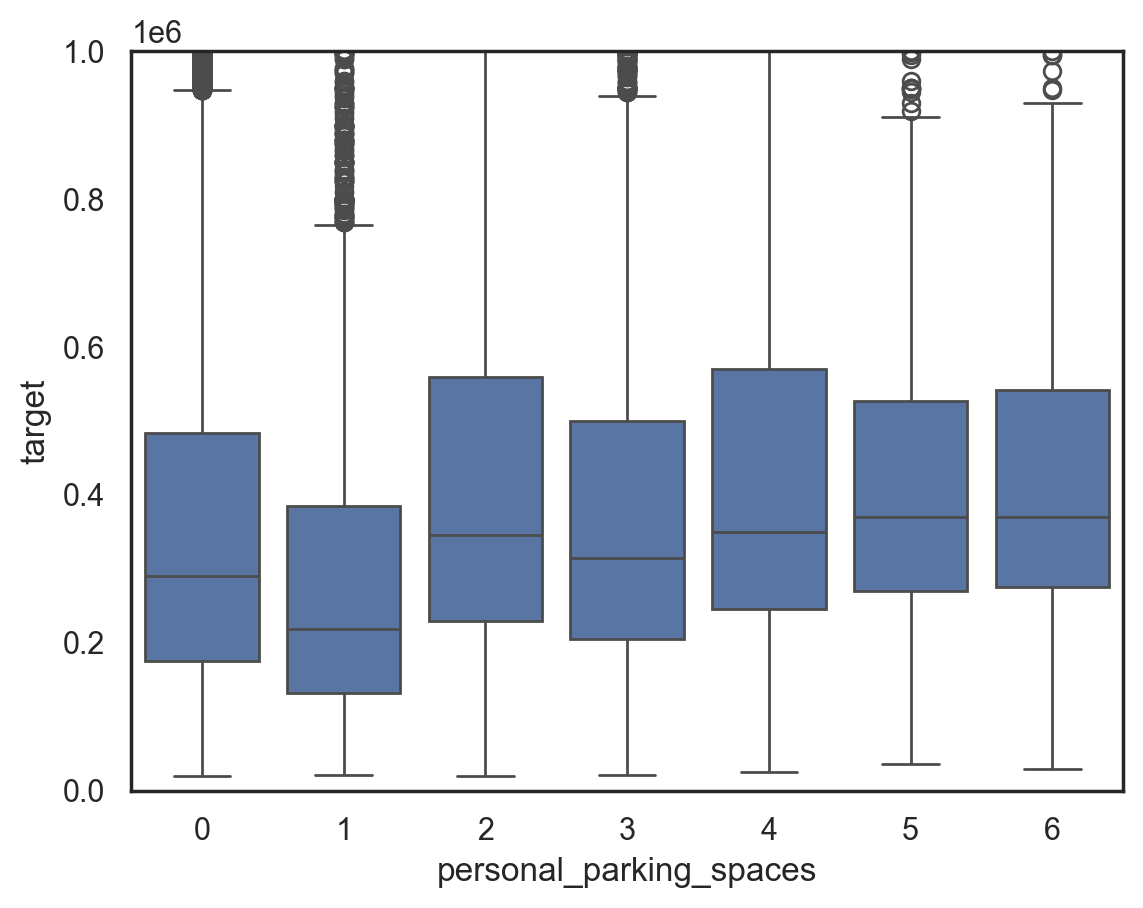

In [52]:
fig = sns.boxplot(x='personal_parking_spaces', y='target', data=data)
fig.axis(ymin=0, ymax=1000000)

Дома без частных парковочных мест (большинство из которых составляют многоквартирные дома с оборудованной парковкой), естественно, стоят дороже небольших частных домов с гаражом на одну машину, но дешевле, чем большие частные дома с большими гаражами на несколько автомобилей. Заметно, что гаражи на три автомобиля стоят немного дешевле гаражей на два автомобиля, но скорее всего это всего лишь небольшой шум в данных, не являющийся критическим.

In [53]:
data = data.drop(labels=['Heating', 'Cooling', 'Parking'], axis=1)

Теперь начнём работать с информацией о ближайшей к дому школе. Часть обработки информации о типе школы мы уже сделали на этапе 1, сейчас настало время завершить работу. Посмотрим на то, какие значения встречаются в созданном нами на этапе 1 признаке nearest_school_type:

In [54]:
data['nearest_school_type'].value_counts()[:10]

nearest_school_type
Elementary      124915
High             38630
Middle           29456
Other            10608
K-8               6393
Intermediate      1525
School            1329
Charter            996
Park               780
Learning           718
Name: count, dtype: int64

Абсолютное большинство составляют начальные школы (Elementary), что объясняется численным превосходством этого типа школ над другими и в действительности. Высшие (High) и средние (Middle) школы занимают второе и третье шесто с огромным отрывом, хотя и очень далеки от пренебрежимо малого меньшинства. Так как на практике для большинства людей нет большой разницы между восьмиклассной (K-8) или Intermediate-школой и обычной средней школой, имеет смысл объединить эти категории с Middle. Остальные значения явно являются артефактами первичной обработки данных и должны быть объединены с Other. 

In [55]:
def school_classifier(string):
    if string in ['Elementary', 'High', 'Middle']:
        return string
    elif string=='K-8' or string=='Intermediate':
        return 'Middle'
    else:
        return 'Unknown'
    
data['nearest_school_type'] = data['nearest_school_type'].apply(school_classifier)  

Теперь можно оценить, как тип ближайшей школы влияет на цену дома.

(-0.5, 3.5, 0.0, 1000000.0)

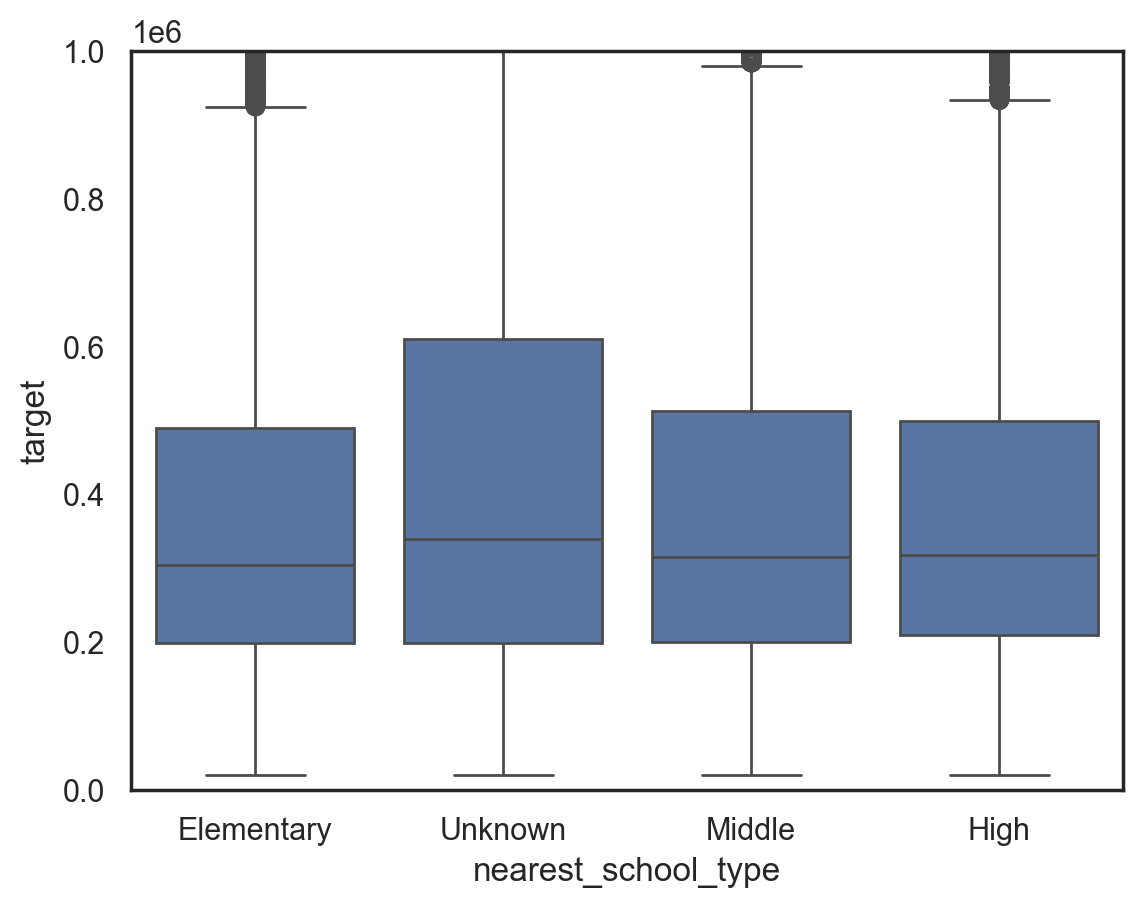

In [56]:
fig = sns.boxplot(x='nearest_school_type', y='target', data=data)
fig.axis(ymin=0, ymax=1000000)

По-видимому, тип ближайшей школы никак не влияет на цену дома. Более высокие цены в категории Unknown, скорее всего, объясняется попаданием в неё больших, дорогих участков земли без построек, у которых в данных не был указан тип ближайшей школы за ненадобностью. Можно даже проверить, так ли это:

In [57]:
land_lots = data[data['land']==1]
land_lots['nearest_school_type'].value_counts()

nearest_school_type
Elementary    2965
Unknown       2285
Middle         841
High           710
Name: count, dtype: int64

Это предположение оказалось неверным, но признак типа ближайшей школы всё равно является малоинформативным и будет удалён из данных.

In [58]:
data = data.drop(labels='nearest_school_type', axis=1)

Теперь оценим, влияет ли на цену дома качество ближайшей школы.

(-0.5, 9.5, 0.0, 1000000.0)

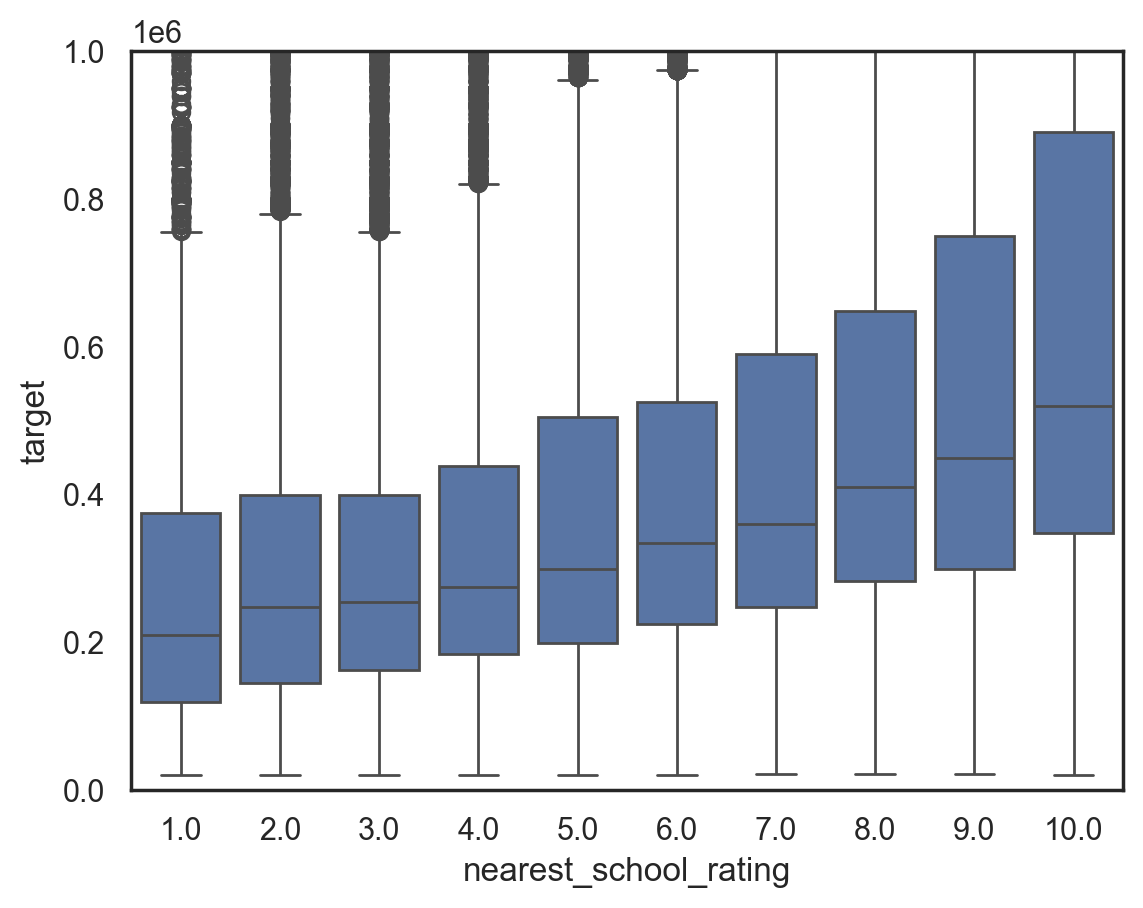

In [59]:
fig = sns.boxplot(x='nearest_school_rating', y='target', data=data)
fig.axis(ymin=0, ymax=1000000)

А вот качество ближайшей школы на цену дома влияет явно. Дома рядом со школой с 10-балльным рейтингом стоят примерно в два раза дороже домов рядом с 5-балльной школой. Это естественно, ведь большинство людей, покупающих дом - семейные люди, которые обычно хотят обеспечить лучшее возможное образование для своих детей. К тому же в дополнение к этому, качество местной школы обычно находится в прямой зависимости от благополучия города или района, которое очевидно напрямую отражается на цене продающегося здесь жилья.

Теперь поработаем с расстоянием до ближайшей школы. Сначала избавимся от пропусков и выбросов в этом признаке.

In [60]:
print(f'The closest school is allegedly in {data['nearest_school_distance'].min()} miles from the home')
print(f'The farthest school is allegedly in {data['nearest_school_distance'].max()} miles from the home')

The closest school is allegedly in 0.0 miles from the home
The farthest school is allegedly in 1590.3 miles from the home


Ближайшая к дому школа "находится" на нулевом от неё расстоянии, что явно не соответствует здравому смыслу. Наиболее далёкая от дома школа "находится" более чем в полутора тысячах миль от него, что также не соответствует зравому смыслу. И то, и другое, явно является выбросами - оценим теперь их количество. Будем считать выбросом любое расстояние больше чем 10 миль или меньше чем 0.1 мили.

In [61]:
print(f'There are {data[data['nearest_school_distance']<0.1].shape[0]} anomalously close schools')
print(f'There are {data[data['nearest_school_distance']>10].shape[0]} anomalously far away schools')


There are 13117 anomalously close schools
There are 1247 anomalously far away schools


Нулевых расстояний в данных слишком много, чтобы просто удалить их из данных. К счастью, их можно легко объяснить ошибкой округления и исправить, заменив на значение в 0.1 мили.

Слишком далёкие школы явно являются ошибкой в самих данных или ошибкой в их парсинге, проведённом нами на этапе 1. Скорее всего, они возникают из-за неправильно поставленной десятичной точки, и истинное значение расстояния, таким образом, ровно в 10 или в 100 раз меньше, чем заявленное. Попробуем исправить значения расстояний, приняв это во внимание.

In [62]:
def fix_distance(d):
    if d<0.1:
        return 0.1
    elif d>100:
        return round(d/100, 1)
    elif d>10:
        return round(d/10, 1)
    else:
        return d
    
data['nearest_school_distance'] = data['nearest_school_distance'].apply(fix_distance)
print(f'There are {data[data['nearest_school_distance']>10].shape[0]} anomalously far away schools')

There are 1 anomalously far away schools


In [63]:
data[data['nearest_school_distance']>10]

,status,street,fireplace,city,sqft,beds,state,stories,target,Year built,...,lotsize,nearest_school_distance,nearest_school_rating,private school,pool,urban_home,suburban_home,rural_home,land,personal_parking_spaces
109380,for sale,108 N Nbelvedere Blvd #29,yes,Santa Ana,890.0,2,TN,2,48640.0,1963.0,...,1481.0,15.9,3.0,0,NaN,0,1,0,0,0


Даже после проведения этой процедуры, дом в почти 16 милях от ближайшей школы, скорее всего, является выбросом (учитывая, что речь идёт о такой относительно густонаселённой стране, как США, да ещё и то, что этот дом находится на бульваре (Blvd)). Удалим его из данных, после чего можно заполнить пропуски в признаке расстояния средним значением, а затем наконец-то оценить, как расстояние до ближайшей школы отражается на цене дома.

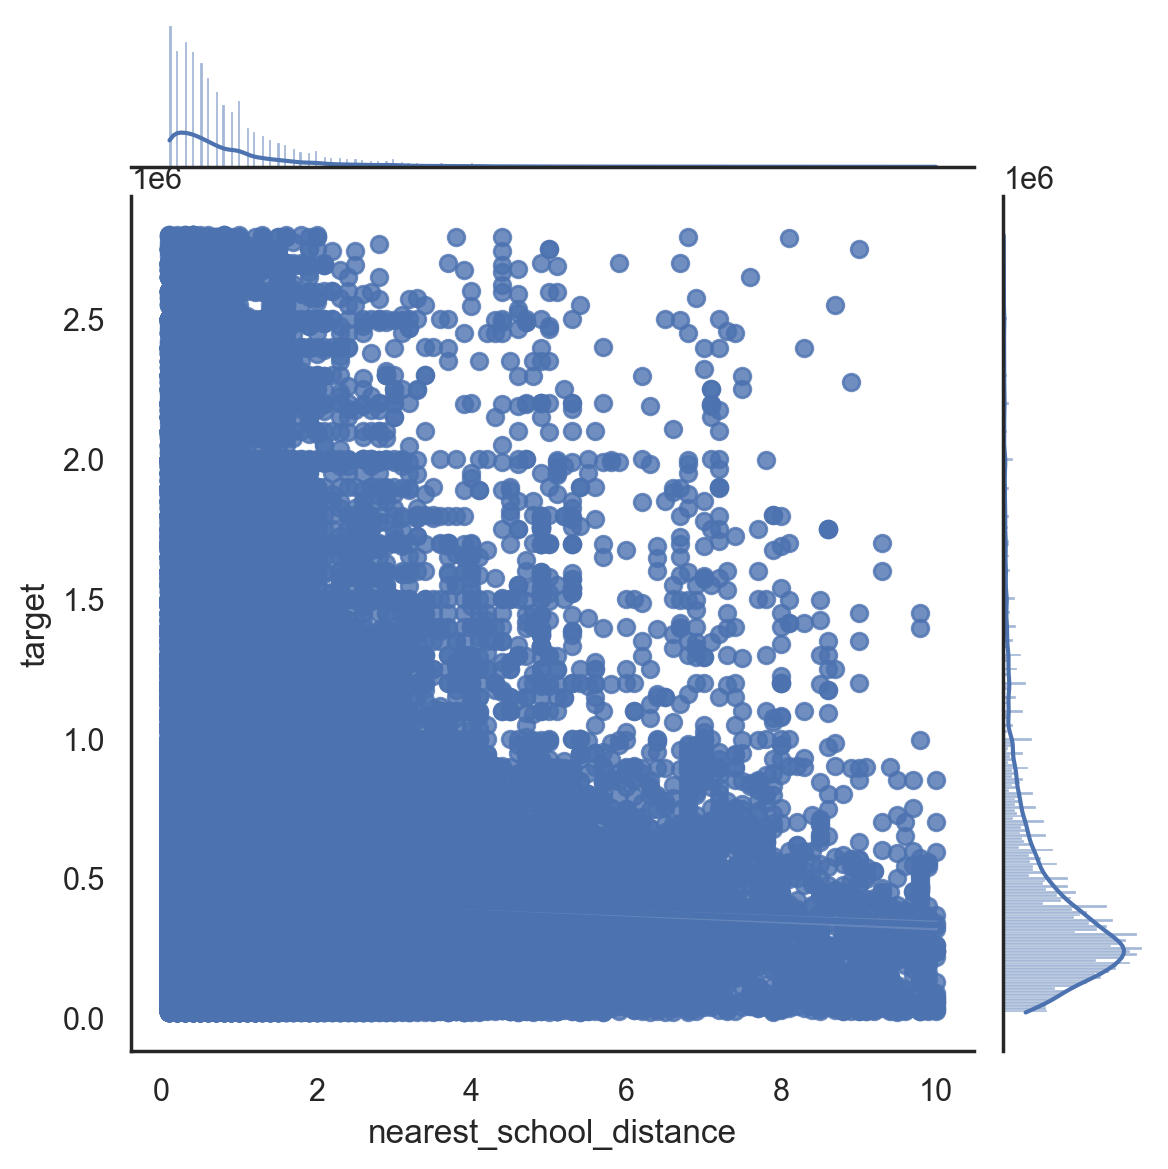

In [64]:
data = data[data['nearest_school_distance']<=10]
data['nearest_school_distance'] = data['nearest_school_distance'].fillna(value=data['nearest_school_distance'].mean())

sns.jointplot(x=data['nearest_school_distance'], y=data['target'], kind='reg')

Несмотря на всё ещё заметное количество шума в данных, хороша видна обратная пропорциональность расстояния до школы и стоимости дома - все наиболее далёкие от школ дома стоят меньше полумиллиона долларов, а практически все сверх-дорогие дома находятся меньше чем в двух=трёх милях от ближайшей школы. Это соостветствует логике - чем ближе дом к школе, тем более он востребован для семьи и, скорее всего, в тем более благополучном месте он находится.

Теперь перейдём к рассмотрению признаков pool (бассейн) и fireplace (камин).

В признаке pool, как мы выяснили в конце этапа 1, огромное количество пропусков. Обычно это вынудило бы нас избавиться от этого признака, но в данном случае есть вероятность, что пропуском обозначается просто отстутствие в доме бассейна. Посмотрим на значения pool, чтобы понять, так ли это:

In [65]:
data['pool'].value_counts()

pool
yes    21035
Yes    11499
Name: count, dtype: int64

Как видно, значения "no" или "No" отсутствуют, что имеет смысл только если отсутствие бассейна обозначается просто пропуском в данных. Тогда признак можно легко преобразовать в бинарный, заменив все пропуски на 0, а непропущенные значения на 1: 

In [66]:
data['pool'] = data['pool'].isna().apply(lambda x: 0 if x==True else 1)

(-0.5, 1.5, 0.0, 1000000.0)

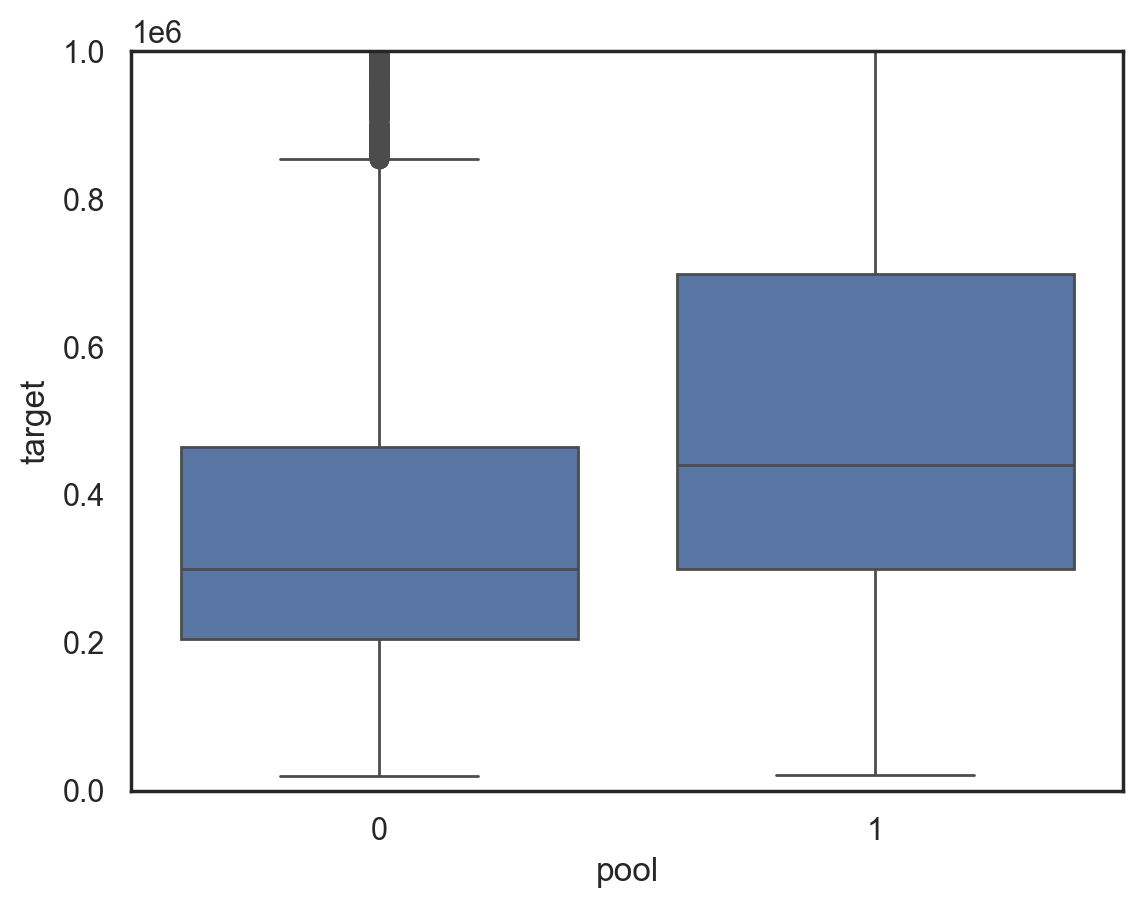

In [67]:
single_family = data[data['suburban_home']==1]

fig = sns.boxplot(x='pool', y='target', data=single_family)
fig.axis(ymin=0, ymax=1000000)

Как видно, частные дома с бассейном обычно стоят намного дороже частных домов без бассейна, что ожидаемо.

Теперь перейдём к признаку fireplace. В нём тоже очень много пропусков, что аналогично может указывать, что пропуском обозначается отсутствие в доме камина. Взглянем на значения, не являющиеся пропусками, чтобы понять, так ли это.

In [68]:
data['fireplace'].value_counts()[:10]

fireplace
yes               37531
Yes               16251
1                  8518
Not Applicable     1761
2                  1189
Fireplace           619
Living Room         310
Wood Burning        219
1 Fireplace         216
LOCATION            215
Name: count, dtype: int64

Значения, явно указывающие на отсутствие камина в доме, есть, но их очень мало, что не соответствует зравому смыслу, подсказывающему, что камин в наше время - это дорогое и довольно сложное в эксплуатации удовольствие, поэтому домов без каминов должно быть намного больше. Также в признаке есть значения, указывающие на количество каминов доме, но использовать эту информацию крайне нецелесообразно из-за очень малого количества домов с более, чем одник камином. Поэтому мы просто преобразуем признак fireplace в бинарный признак, показывающий наличие или отсутствие камина, приняв пропуск за одно из обознаений его отсутствия.

In [69]:
data['fireplace'] = data['fireplace'].fillna(value='No')
data['fireplace'] = data['fireplace'].apply(lambda x: 0 if x=='0' or 'No' in x else 1)
data['fireplace'].value_counts()

fireplace
0    181759
1     71297
Name: count, dtype: int64

(-0.5, 1.5, 0.0, 1000000.0)

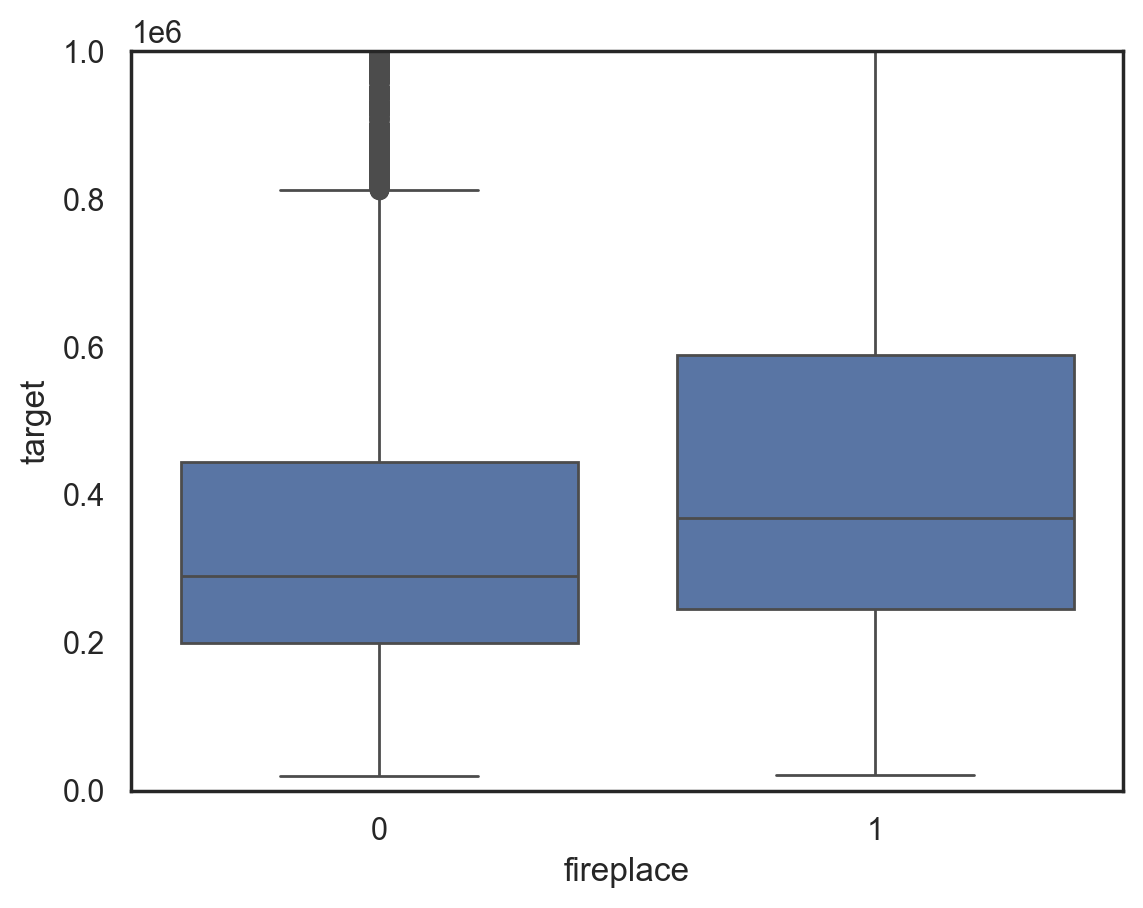

In [70]:
single_family = data[data['suburban_home']==1]

fig = sns.boxplot(x='fireplace', y='target', data=single_family)
fig.axis(ymin=0, ymax=1000000)

Как видно, частные дома с камином также стоят заметно дороже дороже частных домов без камина, хотя разница и не настолько сильна, как между домами с бассейном и без бассейна.

Переёдём к рассмотрению признаков Year built и Remodeled year. Remodeled year - последний из признаков в датасете, большинство значений которого составляют пропуски. Скорее всего, пропуски в этом признаке означают, что дом никогда не ремонитровался/перестраивался. Однако, если дом никогда не ремонтировался, с формальной точки точки зрения можно сказать, что в последний раз он "ремонтировался" (из состояния небытия) одновременно с постройкой. Таким образом, пропуски в Remodeled year можно заполнить соответствующими значениями из Year built.  

In [71]:
data['Remodeled year'] = data['Remodeled year'].fillna(value=data['Year built'])

print(f'Now there are {sum(data['Year built'].isna())} missing Year built values and {sum(data['Remodeled year'].isna())} missing Remodeled year values')

Now there are 21875 missing Year built values and 21711 missing Remodeled year values


Будем считать выбросом любой дом, построенный или отремонтированный "в будущем" (после 2024 года), или же с датой ремонта, меньшей, чем дата постройки.

In [72]:
date_outliers = sum((data['Remodeled year']>2024) | (data['Year built']>2024) | (data['Year built']>data['Remodeled year']))
print(f'There are {date_outliers} date-related outliers')

There are 2068 date-related outliers


Исправим эти выбросы, заменив "проблемные" годовые значения на, скажем, 1990 год, а "невозможные" значения года последнего ремонта заменим на известные нам годы постройки:

In [73]:
data['Year built'] = data['Year built'].apply(lambda x: x if x<2024 else 1990)
data['Remodeled year'] = data['Remodeled year'].apply(lambda x: x if x<2024 else 1990)

wrong_build_year = data[(data['Year built']>data['Remodeled year'])]
data = data[(data['Year built']<=data['Remodeled year'])]

wrong_build_year['Remodeled year'] = wrong_build_year['Year built']
data = pd.concat(objs=[data, wrong_build_year])

Для удобства дальнейшей работы переформатируем оба признака: вместо самого года постройки или последнего ремонта будем использовать количество лет, прошедшее с того времени (за "настоящее время" возьмём 2024 год, в который был совершён сбор исходных данных). После переформатирования признаков заполним пропуски в них наиболее частотным значением.

In [74]:
data['years since remodeling'] = 2024 - data['Remodeled year']
data['building age'] = 2024 - data['Year built']

data['years since remodeling'] = data['years since remodeling'].fillna(value=data['years since remodeling'].mode()[0]) 
data['building age'] = data['building age'].fillna(value=data['building age'].mode()[0])

Теперь избавимся от очень старых домов в наших данных. Будем считать дом слишком старым, если его заявленный возраст превышает полтора столетия.

In [75]:
print(f'There are {sum(data['building age']>150)} anomalously old buildings')

There are 355 anomalously old buildings


In [76]:
data = data[data['building age']<=150]

Посмотрим, как возраст дома и время, прошедшее с последнего ремонта, влияют на его цену:

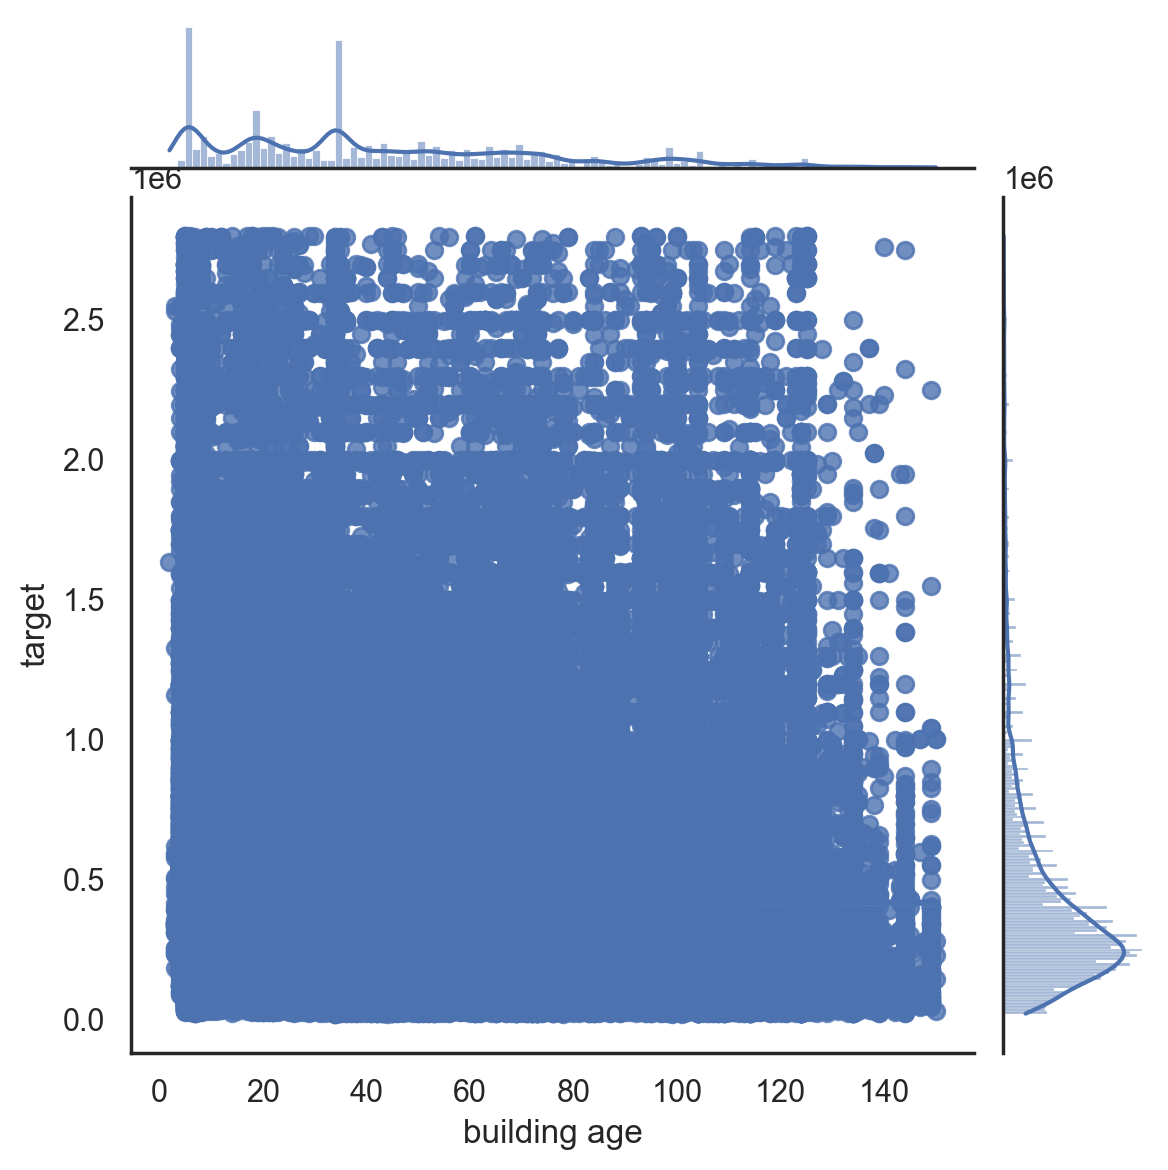

In [77]:
sns.jointplot(x=data['building age'], y=data['target'], kind='reg')

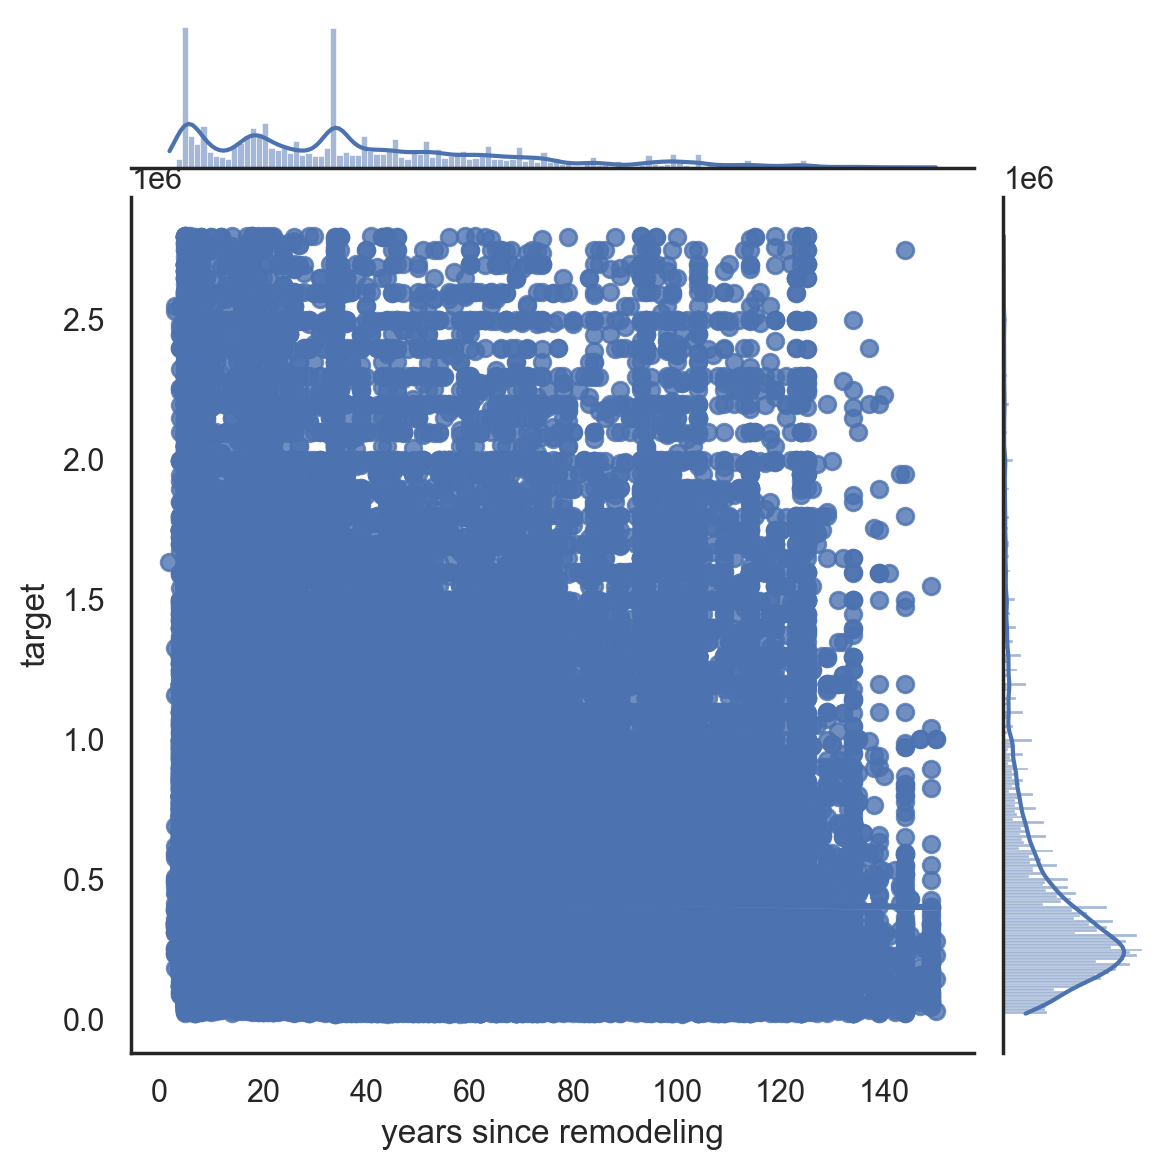

In [78]:
sns.jointplot(x=data['years since remodeling'], y=data['target'], kind='reg')

Ни то, ни другое не влияют на возраст дома практически никак, разве что заметно, что после превышения отметки примерно в 80 лет для обоих признаков стоимость домов резко падает до низких значений. Возможно, это стоит выделить в отдельный бинарный признак, но в целом признаки возраста дома и его последнего ремонта малоинформативны и лучше будет избавиться от них.

In [79]:
data['very old house'] = data['building age'].apply(lambda x: 1 if x>=80 else 0)
data['unrenovated house'] = data['years since remodeling'].apply(lambda x: 1 if x>=80 else 0)

data = data.drop(labels=['Year built', 'Remodeled year', 'building age', 'years since remodeling'], axis=1)

Теперь перейдём к информации о расположении дома. Посмотрим, как выглядят типичные значения в колонке street.

In [80]:
data['street'].sample(10)

148951       25161 Palisade Rd 
96497       935 Hillandale Dr E
162987         33 Montanas Este
236070              53 Slygo Rd
246596     920 South St Apt 312
180056           1546 E 24th St
230461        6915 Kettlemar Dr
272319     4802 Tara Woods Dr E
232736    7070 Royal Meadows St
57576        Slaughter Creek Dr
Name: street, dtype: object

Адрес дома сам по себе для предсказания использоваться не может - ведь он уникален для каждого объекта. Однако он содержит в себе указание типа улицы (St, Dr, Ave и т.д.), обычно - в последнем слове адреса, который потенциально может нести в себе ценную информацию. Попробуем добыть её.

In [81]:
data['street type'] = data['street'].apply(lambda x: x.split()[-1])
data['street type'].value_counts()[:10]

street type
St      37157
Dr      33461
Ave     26891
Rd      13774
Ln      13324
Ct      10476
Way      5128
Pl       5055
Cir      4391
Blvd     3847
Name: count, dtype: int64

Неплохо, но не хотелось бы упускать из виду адреса, у которых тип улицы указан не в конце, а где-то в другом месте - их в данных может быть много. Создадим функцию, которая вычленяет из адреса обозначения наиболее часто встречающихся типов улицы, и для удобства чтения переводит их из сокращений в полные слова. 

In [44]:
street_types = {'St': 'street', 'Dr': 'drive', 'Ave': 'avenue', 'Ln': 'lane', 'Ct': 'crest', 'Blvd': 'boulevard',
                'Rd': 'road', 'Way': 'way', 'N': 'neck', 'Pl': 'plaza', 'Cir' : 'circle', 'Ter' : 'terrace'}

def street_type_searcher(string):
    for suffix in street_types.keys():
        if suffix in string:
            return street_types[suffix]
    return '???'

#data['street type'] = data['street'].apply(street_type_searcher)
#data['street type'].value_counts()

(-0.5, 12.5, 0.0, 1000000.0)

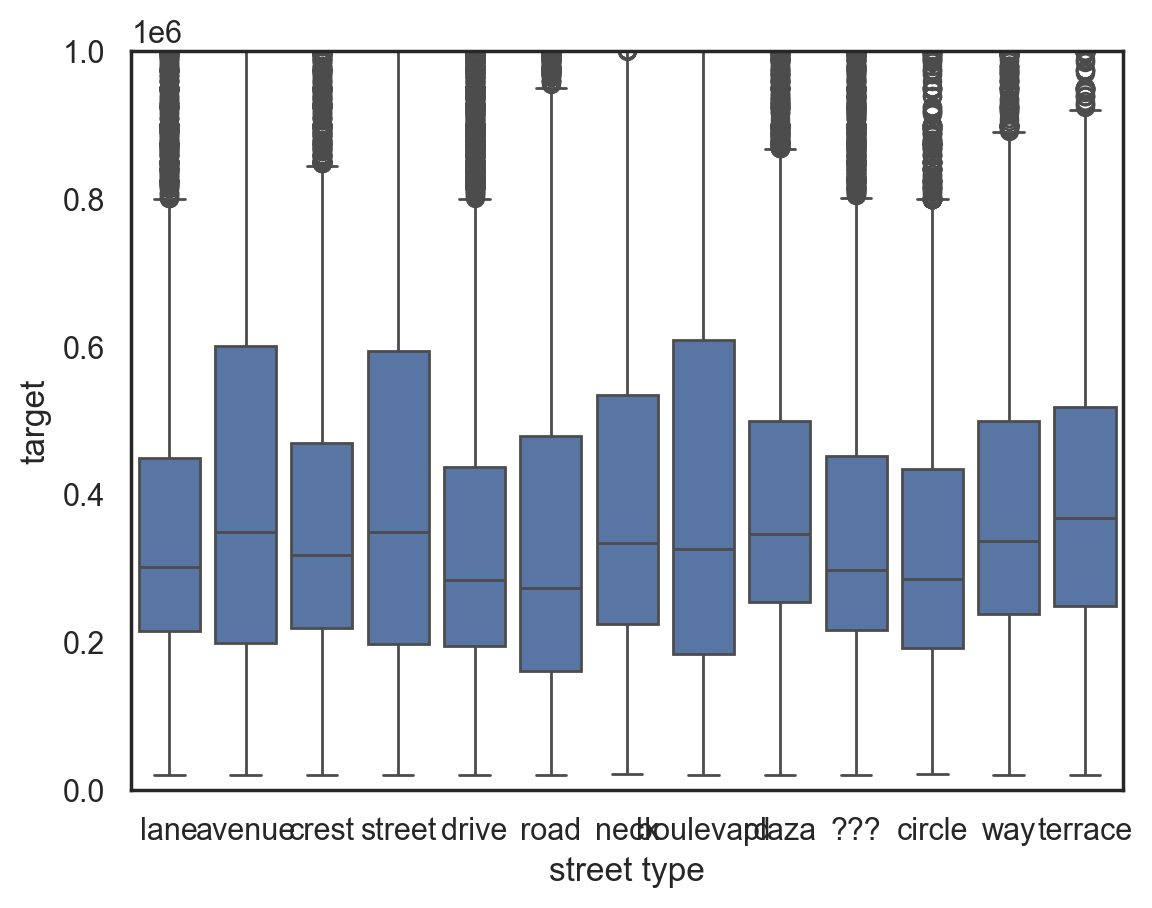

In [83]:
fig = sns.boxplot(x='street type', y='target', data=data)
fig.axis(ymin=0, ymax=1000000)

Чёткой зависимости не прослеживается, однако похоже, что для некоторых типов адресов (например drive - переулок) ценовой диапазон заметно выше, чем для других (например street - обычная улица). Наверное, лучше будет оставить этот признак в данных.

In [84]:
#Сразу переведём этот признак в dummy-формат.
data = pd.get_dummies(data=data, columns=['street type']).drop(labels='street', axis=1)

Перейдём к признаку города. Серьёзную работу с этим признаком мы проведём на этапе 3, а пока просто добавим к названию города название штата, чтобы различать расположенные в разнх штатах города с одинаковыми именами. 

In [85]:
data['state'] = data['state'].fillna(value='??')
data['city'] = data['city'] + ', ' + data['state']

Теперь рассмотрим сам признак штата:

In [86]:
data['state'].value_counts()[:10]

state
FL    80209
TX    57493
CA    16861
NC    14157
NY    11998
TN    11422
WA     9859
OH     8783
NV     6274
IL     5855
Name: count, dtype: int64

Наибольшее число объектов продаётся во Флориде и Техасе - эти два штата лидируют в рейтинге с большим отрывом и вместе составляют около половины от всех данных. Кроме этих двух штатов, имеет смысл выделить Калифорнию, Неваду и Вашингон как штаты, в которых мы ранее обнаружили большое количество домов стоимостью более миллиона долларов, а также штат Нью-Йорк как штат, где находится одноименный город - самый процветающий в США. 

(-0.5, 6.5, 0.0, 1000000.0)

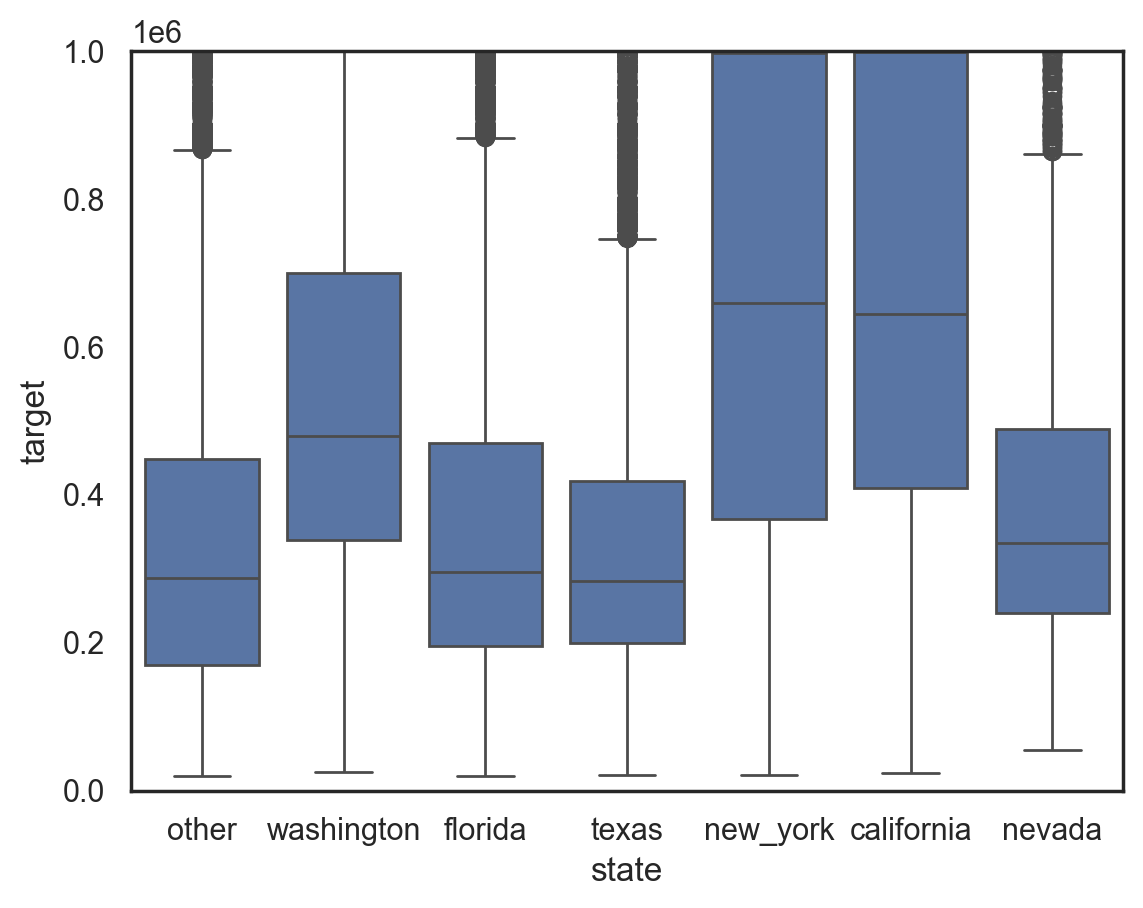

In [87]:
top_states = {'FL':'florida', 'TX':'texas', 'CA':'california',
              'NV': 'nevada', 'WA': 'washington', 'NY':'new_york'}

data['state'] = data['state'].apply(lambda x: top_states[x] if x in top_states.keys() else 'other')

fig = sns.boxplot(x='state', y='target', data=data)
fig.axis(ymin=0, ymax=1000000)

Видно, что дома в Нью-Йорке и Калифорнии стоят намного дороже, чем в остальных штатах - глвным образом за счёт того, что здесь находятся практически все дома стоимостью более 700 тысяч долларов. Дома в Вашингтоне тоже стоят примерно в полтора раза дороже, чем в большинстве остальных штатов страны. А вот Флорида и Техас, несмотря на своё большинство в данных, практически не отличаются от остальных штатов в цене. Итого, имеет смысл выделить среди штатов только Калифорнию, Нью-Йорк, Вашингтон и Неваду (средняя стоимость недвижимости в которой, похоже, слегка выше средней по стране).

In [88]:
data['in_california'] = data['state'].apply(lambda x: 1 if x=='california' else 0)
data['in_new_york'] = data['state'].apply(lambda x: 1 if x=='new_york' else 0)
data['in_washington'] = data['state'].apply(lambda x: 1 if x=='washington' else 0)
data['in_nevada'] = data['state'].apply(lambda x: 1 if x=='nevada' else 0)

data = data.drop(labels='state', axis=1)

Теперь мы наконец-то можем посмотреть на общую картину корелляций в наших данных (за исключением признака города, с которым мы будем работать на третьем этапе).

<Axes: >

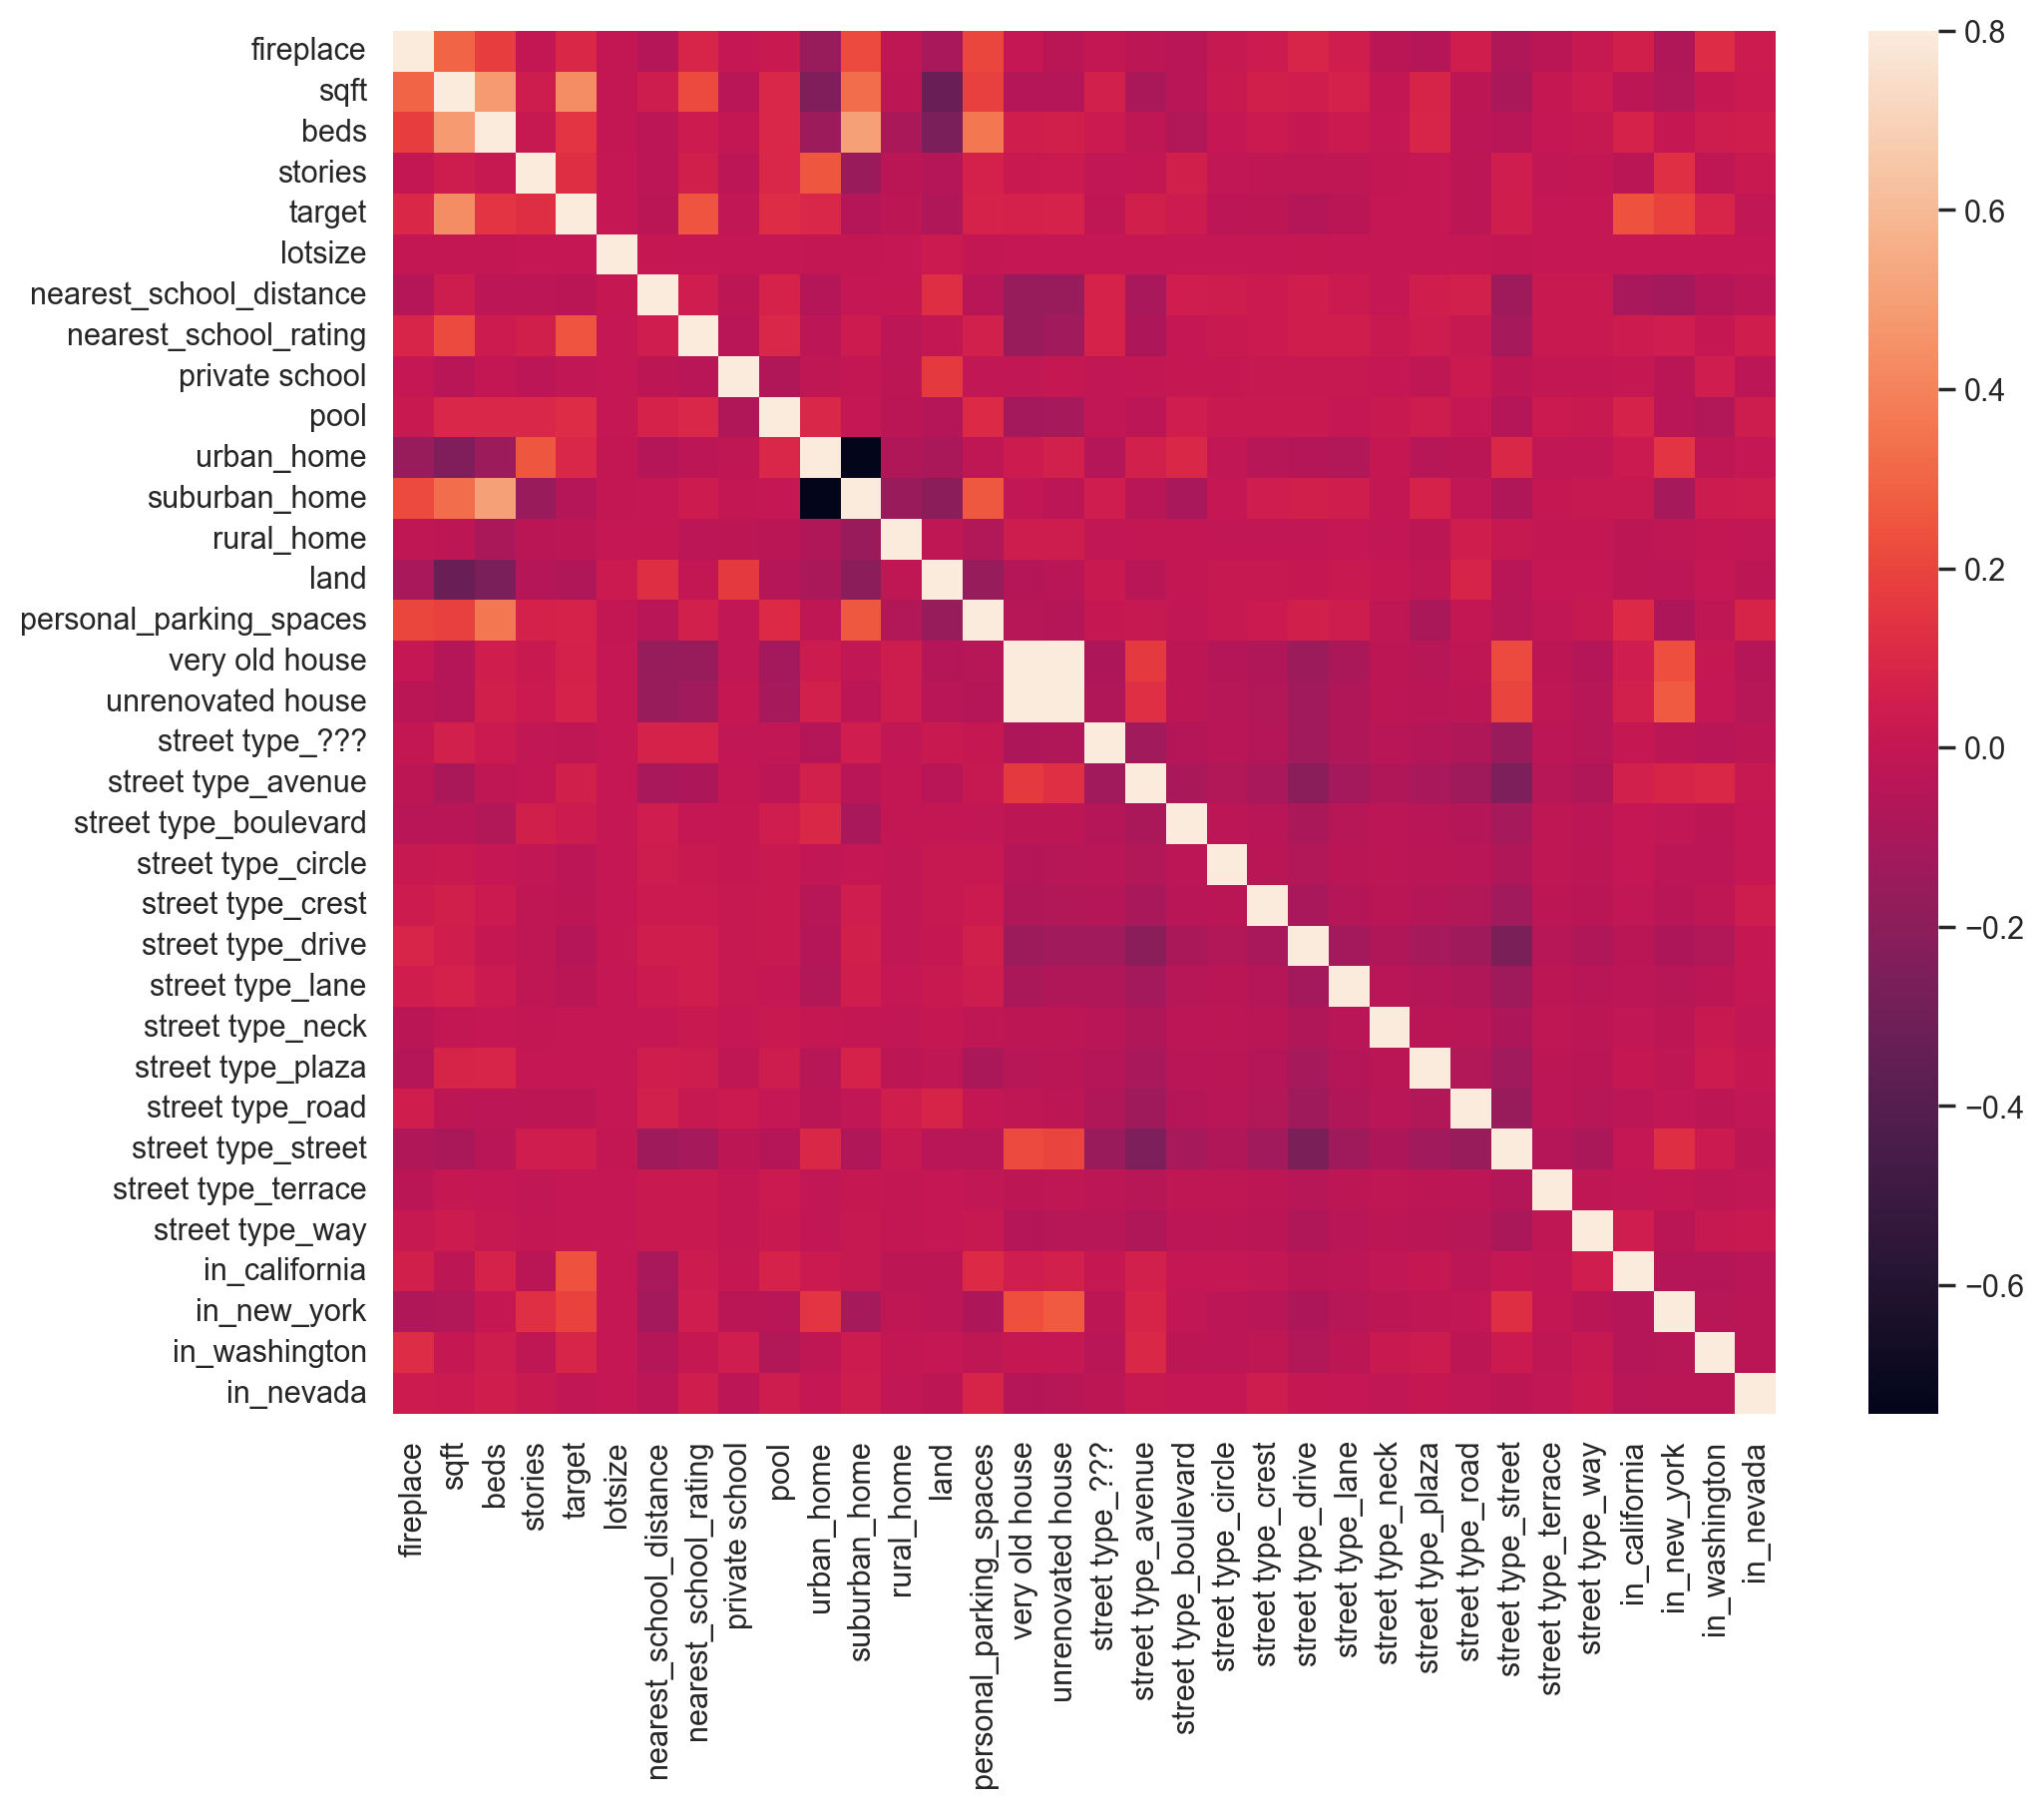

In [89]:
corrmat = data.drop(labels=['status', 'city'], axis=1).corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

*Промежуточные выводы*

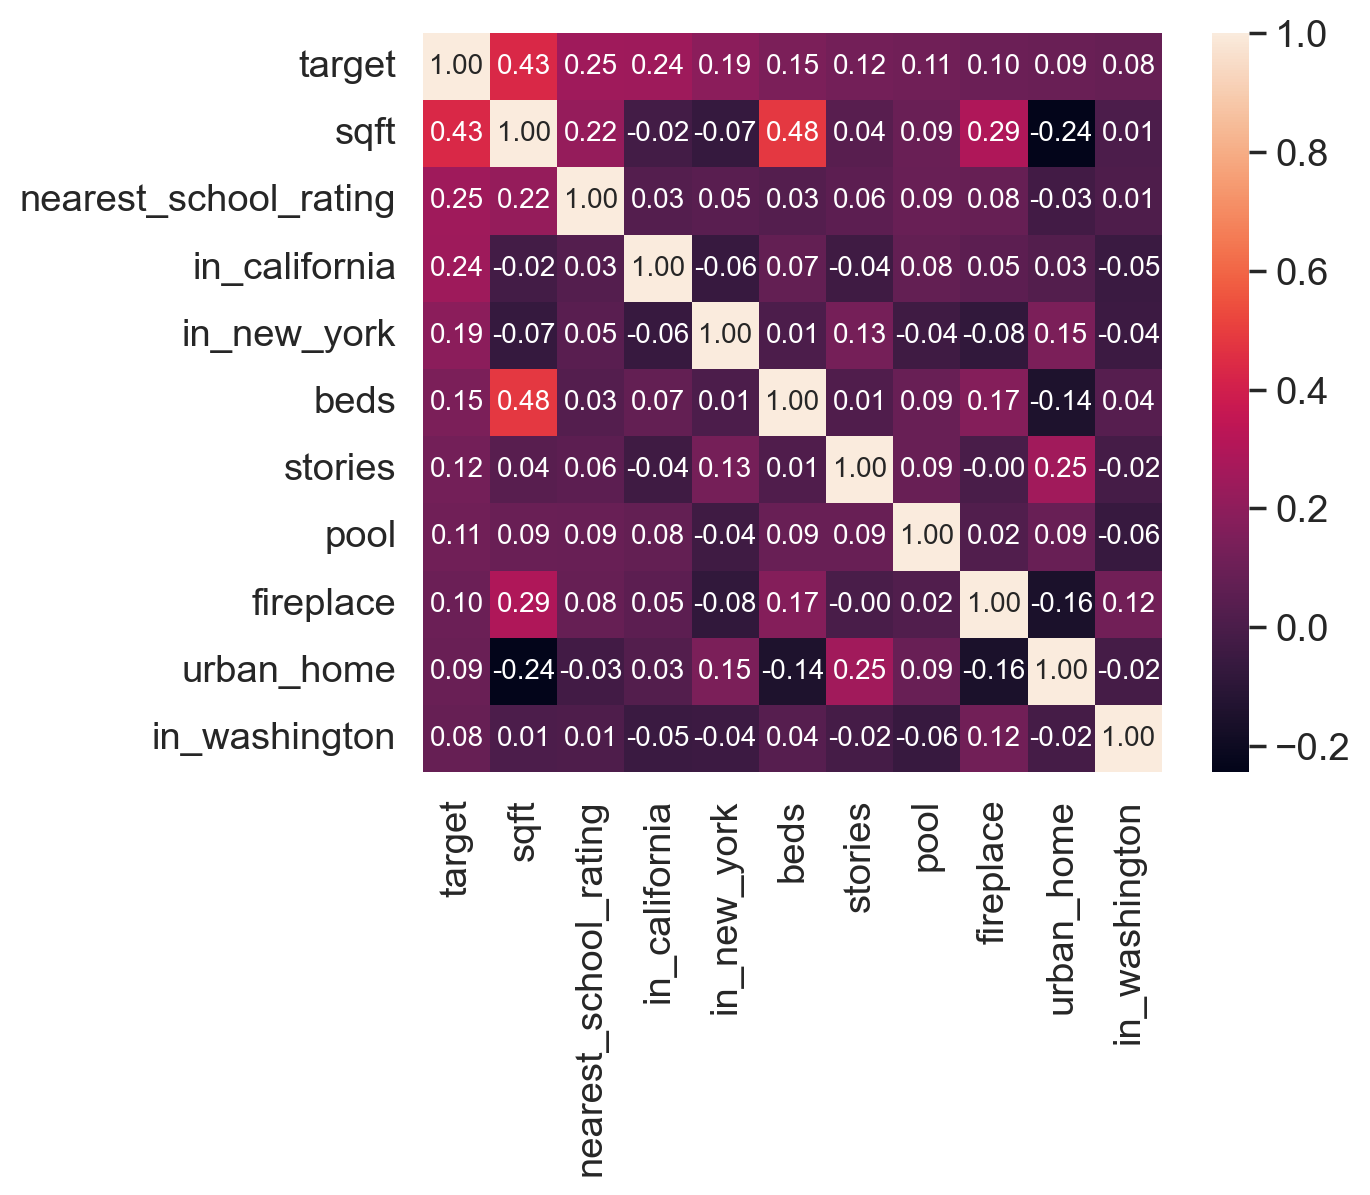

In [90]:
k = 11 
cols = corrmat.nlargest(k, 'target')['target'].index
cm = data[cols].corr()
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [91]:
most_corr = pd.DataFrame(cols)
most_corr.columns = ['Most Correlated Features']
most_corr[1:]

,Most Correlated Features
1,sqft
2,nearest_school_rating
3,in_california
4,in_new_york
5,beds
6,stories
7,pool
8,fireplace
9,urban_home
10,in_washington


In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 252701 entries, 0 to 337160
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   status                   222427 non-null  object 
 1   fireplace                252701 non-null  int64  
 2   city                     252701 non-null  object 
 3   sqft                     252701 non-null  float64
 4   beds                     252701 non-null  int64  
 5   stories                  252701 non-null  int64  
 6   target                   252701 non-null  float64
 7   lotsize                  252701 non-null  float64
 8   nearest_school_distance  252701 non-null  float64
 9   nearest_school_rating    236964 non-null  float64
 10  private school           252701 non-null  int64  
 11  pool                     252701 non-null  int64  
 12  urban_home               252701 non-null  int64  
 13  suburban_home            252701 non-null  int64  
 14  rural_hom

In [93]:
data['nearest_school_rating'] = data['nearest_school_rating'].fillna(value=data['nearest_school_rating'].mode()[0])

In [94]:
x = data.drop(labels=['target', 'city', 'status', 'street type_circle', 'street type_crest', 'street type_lane', 'street type_plaza', 'street type_road', 'street type_neck', 'street type_terrace', 'street type_way'], axis=1)
y = data['target']
x_train, x_test, y_train, y_test = train_test_split(x, y)

model_alpha = GradientBoostingRegressor(random_state=42)
model_alpha.fit(x_train, y_train)

y_pred = model_alpha.predict(x_test)

print(r2_score(y_test, y_pred))

0.4760988228928704


Этап 3.

Нормализация данных.

In [135]:
data['target'] = np.log1p(data['target'])


 mu = 12.66 and sigma = 0.81



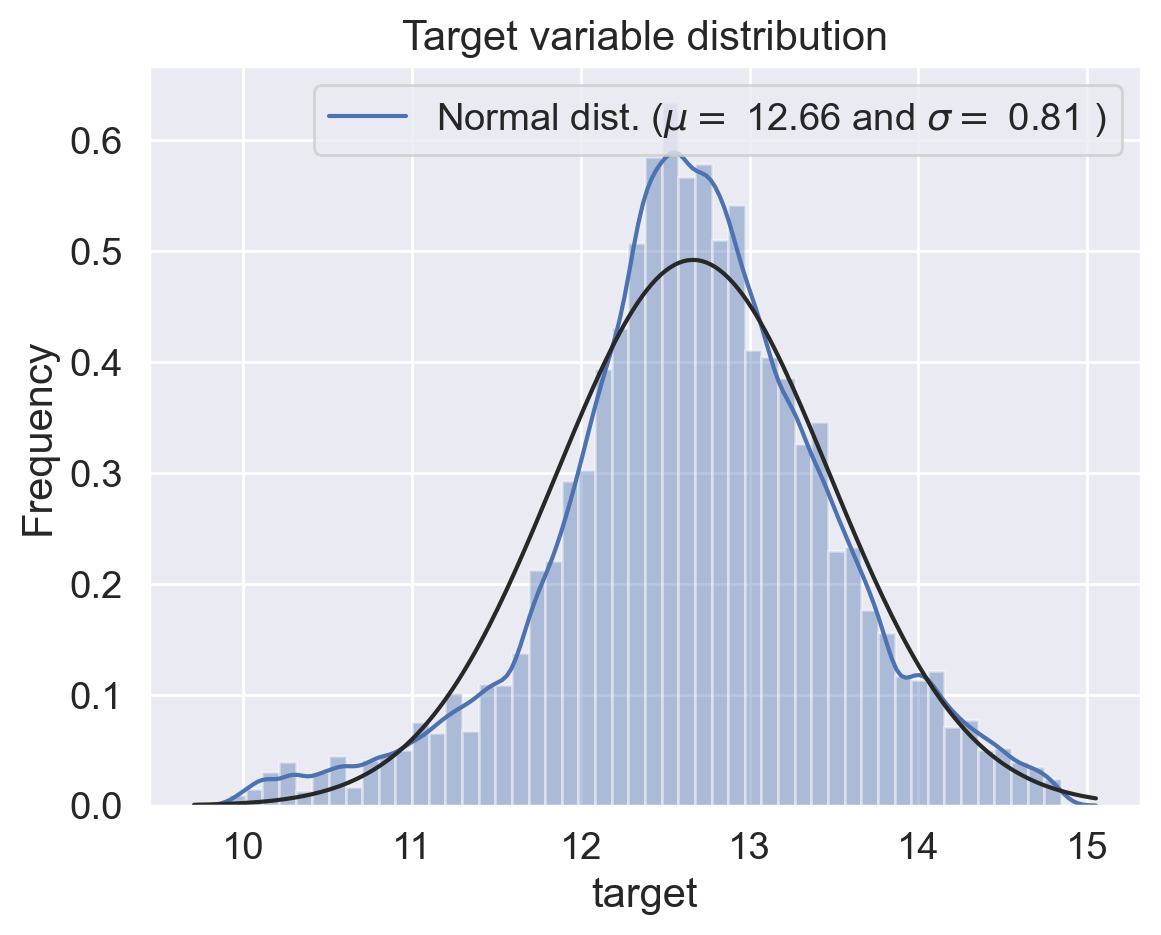

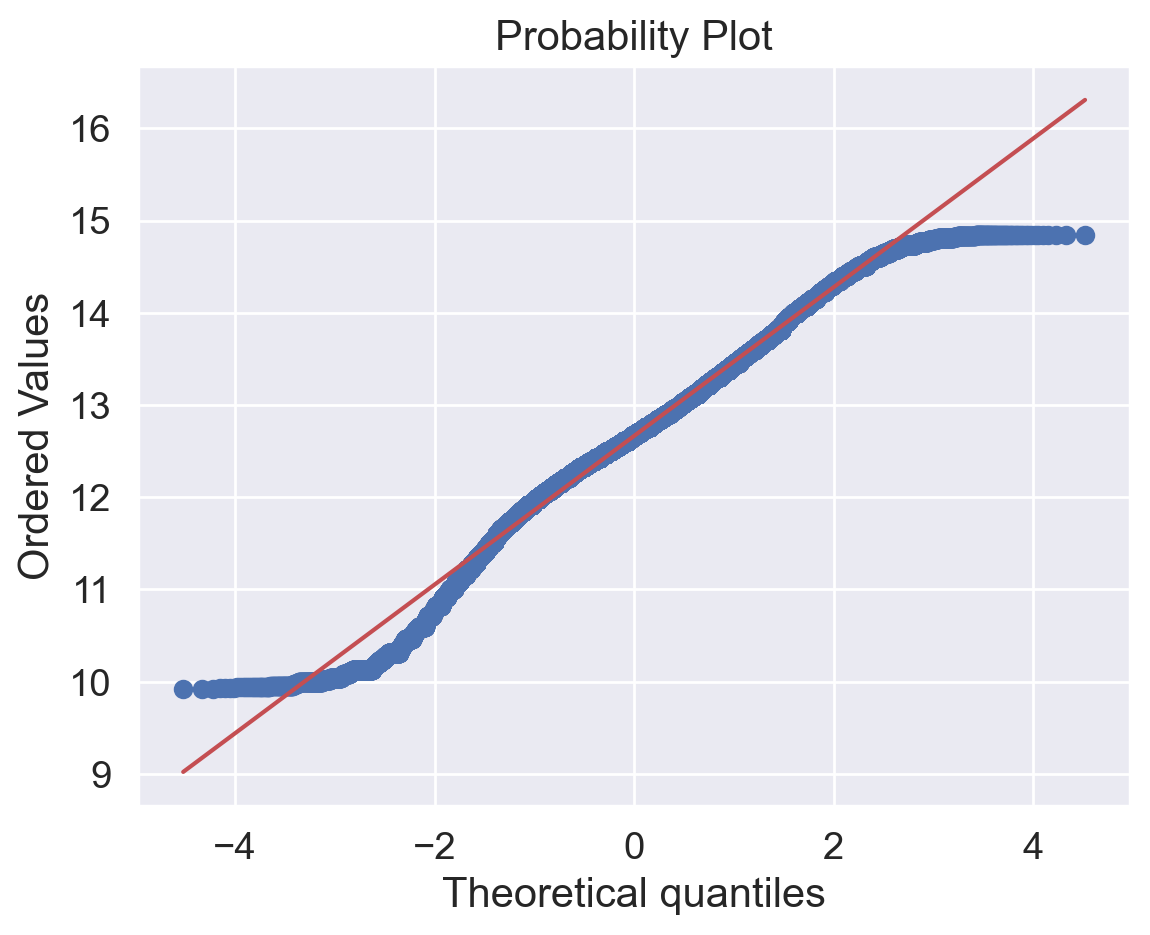

Skewness: -0.257150
Kurtosis: 0.575054


In [136]:
sns.distplot(data['target'], fit=norm)

# Get the fitted parameters used by the function
(mu, sigma) = norm.fit(data['target'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('Target variable distribution')

fig = plt.figure()
res = stats.probplot(data['target'], plot=plt)
plt.show()

print("Skewness: %f" % data['target'].skew())
print("Kurtosis: %f" % data['target'].kurt())

In [137]:
data.columns

Index(['status', 'fireplace', 'city', 'sqft', 'beds', 'stories', 'target',
       'lotsize', 'nearest_school_distance', 'nearest_school_rating',
       'private school', 'pool', 'urban_home', 'suburban_home', 'rural_home',
       'land', 'personal_parking_spaces', 'very old house',
       'unrenovated house', 'street type_???', 'street type_avenue',
       'street type_boulevard', 'street type_drive', 'street type_street',
       'in_california', 'in_new_york', 'in_washington', 'in_nevada',
       'median_age', 'total_population', 'foreign_born', 'Amerind_population',
       'Asian_population', 'Hispanic_population', 'White_population'],
      dtype='object')

In [138]:
numeric_feats = ['beds', 'stories', 'personal_parking_spaces', 'sqft', 'lotsize', 'nearest_school_distance', 
                 'nearest_school_rating', 'median_age', 'total_population', 'foreign_born']

skewed_feats = data[numeric_feats].apply(lambda x: skew(x)).sort_values(ascending=False)
skewness = pd.DataFrame({'Skewed Features' :skewed_feats})
skewness.head(10)

,Skewed Features
lotsize,446.155987
stories,7.607924
foreign_born,5.588846
total_population,3.790875
nearest_school_distance,3.191559
sqft,0.655943
median_age,0.558522
personal_parking_spaces,0.396464
nearest_school_rating,0.273993
beds,-0.060160


In [139]:
skewed_features = []
for feat in skewness.index:
    if abs(skewness.loc[feat, 'Skewed Features']) > 0.75:
        print(feat)
        skewed_features.append(feat)

lotsize
stories
foreign_born
total_population
nearest_school_distance


In [140]:
from scipy.special import boxcox1p
for feat in skewed_features:
    data[feat] = boxcox1p(data[feat], 0.15)
    data[feat] += 1

In [148]:
data.to_csv('data/to_colab.csv')

In [28]:
x = data.drop(labels=['target', 'status', 'city'], axis=1)
y = data['target']
x_train, x_test, y_train, y_test = train_test_split(x, y)

model_baseline = GradientBoostingRegressor(random_state=42)
model_baseline.fit(x_train, y_train)

y_pred = model_baseline.predict(x_test)

print(r2_score(y_test, y_pred))

0.535404138485565


Этап 4.

Моделирование, оценка качества моделей и оформление итоговой модели.

In [3]:
data = pd.read_csv('data/to_colab.csv').drop(labels='Unnamed: 0', axis=1)
data.head()

,fireplace,sqft,beds,stories,target,lotsize,nearest_school_distance,nearest_school_rating,private school,pool,...,in_new_york,in_washington,in_nevada,median_age,total_population,foreign_born,Amerind_population,Asian_population,Hispanic_population,White_population
0,1.0,2900.0,4.0,1.730463,12.943239,16.377360,2.445540,4.0,0.0,0.0,...,0.0,0.0,0.0,33.8,28.173494,16.260496,162.0,1454.25,3109.5,34771.50
1,0.0,1947.0,3.0,2.194318,12.644331,18.809752,1.730463,4.0,0.0,0.0,...,0.0,1.0,0.0,36.0,31.530071,17.635490,2473.0,1336.00,5110.0,91125.00
2,0.0,1507.0,0.0,1.730463,12.109016,14.316713,1.614477,3.0,0.0,0.0,...,0.0,0.0,0.0,39.7,28.089874,16.517843,96.0,816.75,799.5,7521.75
3,0.0,1300.0,3.0,1.730463,13.413541,13.878993,1.095995,2.0,0.0,0.0,...,1.0,0.0,0.0,35.7,27.898146,16.080147,267.0,1122.75,1495.5,9829.50
4,0.0,3130.0,0.0,2.194318,12.468441,16.631092,1.345108,6.0,0.0,0.0,...,0.0,0.0,0.0,32.6,54.330270,44.488983,13157.0,173854.00,1028148.0,1386389.00


In [5]:
data = data.drop(labels= ['median_age',
       'total_population', 'foreign_born', 'Amerind_population',
       'Asian_population', 'Hispanic_population', 'White_population'], axis=1)

In [29]:
from sklearn.ensemble import RandomForestRegressor
forest_model = RandomForestRegressor(n_estimators=100)
forest_model.fit(x_train, y_train)

RandomForestRegressor()

In [31]:
y_pred = forest_model.predict(x_test)

print(r2_score(y_test, y_pred))

0.6315424120488653


In [32]:
forest_model = RandomForestRegressor(n_estimators=100)
forest_model.fit(x, y)

RandomForestRegressor()

In [57]:
valid_data = pd.read_csv('data/house_data_valid.csv').drop(labels= ['Unnamed: 0'], axis=1)
valid_data.head()

,status,propertyType,street,baths,fireplace,city,sqft,beds,state,stories,...,Remodeled year,lotsize,Heating,Cooling,Parking,nearest_school_distance,nearest_school_rating,private school,nearest_school_type,pool
0,for sale,single-family home,918 Courtenay Dr NE,2.0,yes,Atlanta,2252.0,4,GA,2,...,2010.0,7331.0,Forced Air,Central,On Street,0.5,8.0,0,Elementary,NaN
1,Active,NaN,12055 Gandy Blvd N #272,NaN,NaN,ST PETERSBURG,1770.0,0,FL,0,...,2008.0,NaN,Electric,Central Air,NaN,3.5,5.0,0,Elementary,NaN
2,Active,NaN,11918 Midnight Way,NaN,NaN,Huntersville,2433.0,0,NC,0,...,NaN,NaN,NaN,"Central Air, g-Fresh Air Ventilation, Gas (Hot...",NaN,0.3,5.0,0,Blythe,NaN
3,for sale,single-family home,1221 Westridge Rd #B,3.0,yes,Greensboro,1826.0,3,NC,1,...,NaN,1.0,Heat Pump,NaN,NaN,1.6,4.0,0,Elementary,NaN
4,Active,NaN,7100 Sunshine Skyway Ln S #205,NaN,NaN,ST PETERSBURG,1290.0,0,FL,0,...,1984.0,NaN,"Central, Electric",Central Air,NaN,1.3,4.0,0,Middle,NaN


In [58]:
x.columns

Index(['fireplace', 'sqft', 'beds', 'stories', 'lotsize',
       'nearest_school_distance', 'nearest_school_rating', 'private school',
       'pool', 'urban_home', 'suburban_home', 'rural_home', 'land',
       'personal_parking_spaces', 'very old house', 'unrenovated house',
       'street type_???', 'street type_avenue', 'street type_boulevard',
       'street type_drive', 'street type_street', 'in_california',
       'in_new_york', 'in_washington', 'in_nevada'],
      dtype='object')

In [59]:
valid_data.columns

Index(['status', 'propertyType', 'street', 'baths', 'fireplace', 'city',
       'sqft', 'beds', 'state', 'stories', 'target', 'Year built',
       'Remodeled year', 'lotsize', 'Heating', 'Cooling', 'Parking',
       'nearest_school_distance', 'nearest_school_rating', 'private school',
       'nearest_school_type', 'pool'],
      dtype='object')

In [60]:
valid_data = valid_data.drop(labels=['status', 'baths', 'city'], axis=1)

In [61]:
valid_data['fireplace'] = valid_data['fireplace'].isna().apply(lambda x: 0 if x==True else 1)
valid_data['pool'] = valid_data['pool'].isna().apply(lambda x: 0 if x==True else 1)

In [62]:
valid_data['propertyType'] = valid_data['propertyType'].fillna(value='unknown')
valid_data['propertyType'] = valid_data['propertyType'].apply(lambda x: x.lower().replace('-', ' ').replace('family home', 'family'))

In [63]:
valid_data['propertyType'] = valid_data['propertyType'].apply(classify_property)

In [64]:
for prop_type in ['urban_home', 'suburban_home', 'rural_home', 'land']:
    valid_data[prop_type] = valid_data['propertyType'].apply(lambda x: 1 if x==prop_type else 0)

valid_data = valid_data.drop(labels=['propertyType'], axis=1)

In [65]:
valid_data['very old house'] = valid_data['Year built'].apply(lambda x: 1 if x<1944 else 0)
valid_data['unrenovated house'] = valid_data['Remodeled year'].apply(lambda x: 1 if x<1944 else 0)

valid_data = valid_data.drop(labels=['Year built', 'Remodeled year'], axis=1)

In [66]:
valid_data['street type'] = valid_data['street'].apply(street_type_searcher)

for street_type in ['???', 'avenue','boulevard', 'drive', 'street']:
    valid_data['street type_'+street_type] = valid_data['street type'].apply(lambda x: 1 if x==street_type else 0)

valid_data = valid_data.drop(labels=['street type', 'street'], axis=1)

In [67]:
valid_data['in_california'] = valid_data['state'].apply(lambda x: 1 if x=='CA' else 0)
valid_data['in_new_york'] = valid_data['state'].apply(lambda x: 1 if x=='NY' else 0)
valid_data['in_washington'] = valid_data['state'].apply(lambda x: 1 if x=='WA' else 0)
valid_data['in_nevada'] = valid_data['state'].apply(lambda x: 1 if x=='NV' else 0)

valid_data = valid_data.drop(labels='state', axis=1)

In [68]:
valid_data['Parking'] = valid_data['Parking'].apply(parking_spaces_parser)    
valid_data['personal_parking_spaces'] = valid_data['Parking'].apply(lambda x: int(x.split()[0]) if x.split()[0].isnumeric() else 0)

In [69]:
valid_data = valid_data.drop(labels=['Heating', 'Cooling', 'Parking', 'nearest_school_type'], axis=1)

In [70]:
valid_data.columns

Index(['fireplace', 'sqft', 'beds', 'stories', 'target', 'lotsize',
       'nearest_school_distance', 'nearest_school_rating', 'private school',
       'pool', 'urban_home', 'suburban_home', 'rural_home', 'land',
       'very old house', 'unrenovated house', 'street type_???',
       'street type_avenue', 'street type_boulevard', 'street type_drive',
       'street type_street', 'in_california', 'in_new_york', 'in_washington',
       'in_nevada', 'personal_parking_spaces'],
      dtype='object')

In [71]:
for column in valid_data.columns:
    fill_with = valid_data[column].mode()[0]
    valid_data[column] = valid_data[column].fillna(value=fill_with)

In [77]:
valid_data['target'] = np.log1p(valid_data['target'])

from scipy.special import boxcox1p
for feat in ['lotsize', 'stories', 'nearest_school_distance']:
    valid_data[feat] = boxcox1p(valid_data[feat], 0.15)
    valid_data[feat] += 1

In [78]:
x_valid = valid_data.drop(labels='target', axis=1)
y_valid = valid_data['target']

x_valid = x_valid[x.columns]

y_pred = forest_model.predict(x_valid)

In [79]:
print(r2_score(y_valid, y_pred))

-23095.14265335384
